<a href="https://colab.research.google.com/github/Ashu-42/quant_research_crypto_volatility_forecasting/blob/quant_DL_ashu/notebooks/15min/05_Intraday_GRU_FINAL_CORRECTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 05 — Final Enhanced Intraday GRU

This notebook develops the GRU directly on the stronger volatility formulation established by the final MLP.

## Model design

The GRU has two branches:

1. **Causal local sequence branch**  
   A GRU reads only observations available up to forecast origin \(t\).

2. **Long-memory volatility-state branch**  
   Multi-horizon RV, range, semivariance, activity and known-ahead clock features are fused with the GRU output.

A lightweight temporal-attention layer reweights only the already-observed GRU states. It does not see any future candle.

## Target and loss

The target remains:

\[
RV_{t+1}=r_{t+1}^2.
\]

The model trains on deseasonalized variance and minimizes a Gaussian variance quasi-likelihood objective aligned with QLIKE.

## Leakage policy

- inner tuning is the last 180 days of the original Train period;
- inner seasonality factors are estimated only before that inner tuning window;
- sequence duration, learning rate and epochs are selected inside Train;
- official Validation is evaluated only after the GRU configuration is frozen;
- Test is untouched.

## Dynamic-time design

Sequence histories are specified as elapsed durations. The notebook automatically keeps only durations corresponding to 4–32 bars for the active candle interval.

Examples:

- 15m candles → 1h/2h/4h/8h become 4/8/16/32 bars.
- 1h candles → 4h/8h/12h/1d become 4/8/12/24 bars.

> **Corrected target-alignment logic:** the full historical feature table may retain rows around exchange gaps. Strict one-candle-ahead target QC is therefore applied to Notebook 02's canonical valid model rows, while non-canonical full-history rows may remain only as past sequence context and can never become supervised forecast endpoints.


## 1. Imports and reproducibility

In [1]:
from google.colab import drive
from pathlib import Path
from datetime import datetime, timezone
import gc, json, math, os, random, time, warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

import tensorflow as tf
from tensorflow.keras import Model
from tensorflow.keras.layers import Input, GRU, Dense, Dropout, LayerNormalization, Concatenate
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.initializers import Constant

drive.mount("/content/drive")

BASE_SEED = 52
os.environ["PYTHONHASHSEED"] = str(BASE_SEED)
random.seed(BASE_SEED)
np.random.seed(BASE_SEED)
tf.keras.utils.set_random_seed(BASE_SEED)

try:
    tf.config.experimental.enable_op_determinism()
    print("TensorFlow deterministic operations enabled.")
except Exception as e:
    print("Deterministic-op request unavailable:", e)

print("TensorFlow:", tf.__version__)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
TensorFlow deterministic operations enabled.
TensorFlow: 2.20.0


## 2. Configuration

In [2]:
PROJECT_ROOT = Path("/content/drive/MyDrive/Quant Research/15min")
KLINE_INTERVAL = "15m"

SYMBOLS = ["BTCUSDT","ETHUSDT","SOLUSDT","XRPUSDT"]
EPSILON = 1e-12

INNER_TUNING_DURATION = pd.Timedelta(days=180)

SEQUENCE_DURATION_CANDIDATES = ["1h","2h","4h","8h","12h","1d"]
MIN_SEQUENCE_BARS = 4
MAX_SEQUENCE_BARS = 32

LOOKBACK_SELECTION_LR = 3e-4
LEARNING_RATE_CANDIDATES = [3e-4,1e-4]

RV_STATE_DURATIONS = ["30min","1h","2h","4h","8h","12h","1d"]
RANGE_DURATIONS = ["1h","4h","1d"]
SEMIVAR_DURATIONS = ["1h","4h","1d"]
ACTIVITY_DURATIONS = ["4h","1d"]
LAG_DURATIONS = ["30min","1h","2h","4h"]

BATCH_SIZE = 1024
MAX_INNER_EPOCHS = 70
EARLY_STOPPING_PATIENCE = 7
LR_PATIENCE = 3
MIN_LEARNING_RATE = 1e-6
WEIGHT_DECAY = 1e-5
CLIPNORM = 1.0

GRU_UNITS = 64
SEQUENCE_DROPOUT = 0.08
STATE_DROPOUT = 0.08
HEAD_DROPOUT = 0.05

ROLLING_VOLATILITY_WINDOW = "1d"
PLOT_WINDOW_DURATION = "14d"
PLOT_START = None

MANIFEST_ROOT = PROJECT_ROOT / "manifests" / KLINE_INTERVAL
MODEL_READY_ROOT = PROJECT_ROOT / "data" / "model_ready" / KLINE_INTERVAL
MODEL_ROOT = PROJECT_ROOT / "models" / KLINE_INTERVAL / "GRU_FINAL"
ARTIFACT_ROOT = PROJECT_ROOT / "artifacts" / KLINE_INTERVAL / "GRU_FINAL"
RESULTS_ROOT = PROJECT_ROOT / "results" / KLINE_INTERVAL / "GRU_FINAL"
INNER_RESULTS_ROOT = RESULTS_ROOT / "inner_tuning"

for d in [MODEL_READY_ROOT,MODEL_ROOT,ARTIFACT_ROOT,RESULTS_ROOT,INNER_RESULTS_ROOT]:
    d.mkdir(parents=True, exist_ok=True)

print("Project:", PROJECT_ROOT)
print("Interval:", KLINE_INTERVAL)

Project: /content/drive/MyDrive/Quant Research/15min
Interval: 15m


## 3. Load upstream data

In [3]:
manifest_candidates = sorted(
    MANIFEST_ROOT.glob(
        f"processing_manifest_{KLINE_INTERVAL}_v*.json"
    )
)

if len(manifest_candidates) != 1:
    raise FileNotFoundError(
        "Expected exactly one processing manifest for "
        f"{KLINE_INTERVAL}; found {len(manifest_candidates)}."
    )

PROCESSING_MANIFEST_PATH = manifest_candidates[0]

processing_manifest = json.loads(
    PROCESSING_MANIFEST_PATH.read_text(
        encoding="utf-8"
    )
)

if (
    processing_manifest["kline_interval"]
    != KLINE_INTERVAL
):
    raise ValueError(
        "Processing-manifest interval mismatch."
    )

INTERVAL_MINUTES = int(
    processing_manifest["interval_minutes"]
)

INTERVAL_MS = int(
    processing_manifest["interval_ms"]
)

INTERVAL_DELTA = pd.Timedelta(
    minutes=INTERVAL_MINUTES
)

split_cfg = (
    processing_manifest[
        "split_boundaries_utc"
    ]
)

VALIDATION_START = pd.Timestamp(
    split_cfg[
        "validation_target_start"
    ]
)

TEST_START = pd.Timestamp(
    split_cfg[
        "validation_target_end_exclusive"
    ]
)

TEST_END_EXCLUSIVE = pd.Timestamp(
    split_cfg[
        "test_target_end_exclusive"
    ]
)

INNER_TUNE_START = (
    VALIDATION_START
    - INNER_TUNING_DURATION
)

FEATURES_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "full_features_parquet"
    ]
)

MODEL_ROWS_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "valid_model_rows_parquet"
    ]
)

SEASONALITY_PATH = Path(
    processing_manifest[
        "outputs"
    ][
        "seasonality_factors_parquet"
    ]
)

RAW_PATH = Path(
    processing_manifest[
        "source_raw_parquet"
    ]
)

for required_path in [
    FEATURES_PATH,
    MODEL_ROWS_PATH,
    SEASONALITY_PATH,
    RAW_PATH,
]:
    if not required_path.exists():
        raise FileNotFoundError(
            required_path
        )


features_df = pd.read_parquet(
    FEATURES_PATH
)

canonical_model_rows_df = pd.read_parquet(
    MODEL_ROWS_PATH
)

full_train_seasonality_df = pd.read_parquet(
    SEASONALITY_PATH
)

raw_df = pd.read_parquet(
    RAW_PATH
)


for frame in [
    features_df,
    canonical_model_rows_df,
]:
    frame[
        "open_time"
    ] = pd.to_datetime(
        frame[
            "open_time"
        ],
        utc=True,
        errors="raise",
    )

    frame[
        "target_open_time"
    ] = pd.to_datetime(
        frame[
            "target_open_time"
        ],
        utc=True,
        errors="coerce",
    )

raw_df[
    "open_time"
] = pd.to_datetime(
    raw_df[
        "open_time"
    ],
    utc=True,
    errors="raise",
)


print(
    "Interval:",
    INTERVAL_DELTA,
)

print(
    "Inner tune:",
    INNER_TUNE_START,
    "to",
    VALIDATION_START,
)

print(
    "Validation:",
    VALIDATION_START,
    "to",
    TEST_START,
)


# ============================================================
# Upstream schema QC
# ============================================================

_required_full_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "return",
    "realized_variance",
    "target_return",
    "target_realized_variance",
    "standard_duration_candle",
}

_required_model_columns = {
    "symbol",
    "open_time",
    "target_open_time",
    "split",
    "target_return",
    "target_realized_variance",
}

_missing_full = (
    _required_full_columns
    - set(
        features_df.columns
    )
)

_missing_model = (
    _required_model_columns
    - set(
        canonical_model_rows_df.columns
    )
)

if _missing_full:
    raise ValueError(
        "Full-feature parquet is missing: "
        f"{_missing_full}"
    )

if _missing_model:
    raise ValueError(
        "Canonical model-row parquet is missing: "
        f"{_missing_model}"
    )


assert not features_df.duplicated(
    [
        "symbol",
        "open_time",
    ]
).any()

assert not canonical_model_rows_df.duplicated(
    [
        "symbol",
        "open_time",
    ]
).any()


# ============================================================
# IMPORTANT:
# full_features_parquet intentionally retains historical rows
# around exchange gaps. For such rows, target_open_time can be
# the next OBSERVED candle and therefore be > one interval away.
#
# The strict one-candle-ahead assertion belongs on Notebook 02's
# VALID MODEL ROWS, not on every row of the full historical table.
# ============================================================

_canonical_alignment = (
    canonical_model_rows_df[
        "target_open_time"
    ]
    - canonical_model_rows_df[
        "open_time"
    ]
)

if not _canonical_alignment.eq(
    INTERVAL_DELTA
).all():
    bad = (
        canonical_model_rows_df.loc[
            ~_canonical_alignment.eq(
                INTERVAL_DELTA
            ),
            [
                "symbol",
                "open_time",
                "target_open_time",
            ],
        ]
        .head(10)
    )

    raise ValueError(
        "Canonical Notebook 02 model rows contain "
        "non-one-candle targets.\n"
        f"{bad}"
    )


# Target identity on the canonical prediction rows.
_target_identity_ok = np.allclose(
    canonical_model_rows_df[
        "target_realized_variance"
    ].to_numpy(
        dtype=float
    ),
    (
        canonical_model_rows_df[
            "target_return"
        ].to_numpy(
            dtype=float
        )
        ** 2
    ),
    rtol=1e-10,
    atol=1e-18,
    equal_nan=False,
)

if not _target_identity_ok:
    raise ValueError(
        "Canonical target variance is not equal "
        "to squared next-candle return."
    )


# Split boundaries are checked only on canonical valid targets.
_train_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "train"
    )
)

_validation_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "validation"
    )
)

_test_mask = (
    canonical_model_rows_df[
        "split"
    ].eq(
        "test"
    )
)

assert canonical_model_rows_df.loc[
    _train_mask,
    "target_open_time",
].lt(
    VALIDATION_START
).all()

assert canonical_model_rows_df.loc[
    _validation_mask,
    "target_open_time",
].ge(
    VALIDATION_START
).all()

assert canonical_model_rows_df.loc[
    _validation_mask,
    "target_open_time",
].lt(
    TEST_START
).all()

assert canonical_model_rows_df.loc[
    _test_mask,
    "target_open_time",
].ge(
    TEST_START
).all()

assert canonical_model_rows_df.loc[
    _test_mask,
    "target_open_time",
].lt(
    TEST_END_EXCLUSIVE
).all()


# ============================================================
# Mark the full historical rows that Notebook 02 accepts as
# legitimate fixed-horizon model targets.
#
# We still retain all full-feature rows as potential PAST context
# for GRU sequences, but only canonical_model_row=True can be a
# forecast endpoint / supervised target.
# ============================================================

_canonical_keys = (
    canonical_model_rows_df[
        [
            "symbol",
            "open_time",
        ]
    ]
    .copy()
)

_canonical_keys[
    "canonical_model_row"
] = True

features_df = (
    features_df
    .merge(
        _canonical_keys,
        on=[
            "symbol",
            "open_time",
        ],
        how="left",
        validate="one_to_one",
    )
)

features_df[
    "canonical_model_row"
] = (
    features_df[
        "canonical_model_row"
    ]
    .fillna(
        False
    )
    .astype(bool)
)


if int(
    features_df[
        "canonical_model_row"
    ].sum()
) != len(
    canonical_model_rows_df
):
    raise ValueError(
        "Canonical model-row mapping back to the "
        "full feature table is incomplete."
    )


_full_alignment = (
    features_df[
        "target_open_time"
    ]
    - features_df[
        "open_time"
    ]
)

features_df[
    "target_interval_valid"
] = (
    features_df[
        "target_open_time"
    ]
    .notna()
    & _full_alignment.eq(
        INTERVAL_DELTA
    )
)


# Every canonical target must be exactly one configured candle ahead.
assert features_df.loc[
    features_df[
        "canonical_model_row"
    ],
    "target_interval_valid",
].all()


_noncanonical_nonunit = int(
    (
        features_df[
            "target_open_time"
        ]
        .notna()
        & ~features_df[
            "target_interval_valid"
        ]
    )
    .sum()
)

print(
    "Canonical fixed-horizon model rows:",
    len(
        canonical_model_rows_df
    ),
)

print(
    "Full-history rows with a non-unit next-observed gap:",
    _noncanonical_nonunit,
)

print(
    "Canonical target/split alignment QC passed."
)

Interval: 0 days 00:15:00
Inner tune: 2024-02-03 00:00:00+00:00 to 2024-08-01 00:00:00+00:00
Validation: 2024-08-01 00:00:00+00:00 to 2025-08-01 00:00:00+00:00
Canonical fixed-horizon model rows: 1114295
Full-history rows with a non-unit next-observed gap: 102
Canonical target/split alignment QC passed.


/tmp/ipykernel_43754/2312288550.py:424: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  .fillna(


## 4. Merge richer raw OHLC/activity fields

In [4]:
raw_extra = raw_df[[
    "symbol","open_time_ms","open","high","low",
    "quote_asset_volume","number_of_trades","taker_buy_quote_asset_volume"
]].copy()

base_df = (
    features_df
    .merge(raw_extra, on=["symbol","open_time_ms"], how="left", validate="one_to_one")
    .sort_values(["symbol","open_time"])
    .reset_index(drop=True)
)

required = [
    "open","high","low","quote_asset_volume",
    "number_of_trades","taker_buy_quote_asset_volume"
]
if base_df[required].isna().any().any():
    raise ValueError("Unexpected nulls after raw-data merge.")

assert not base_df.duplicated(["symbol","open_time_ms"]).any()
print("Merged rows:", len(base_df))

Merged rows: 1125147


## 5. Dynamic duration helpers

In [5]:
def duration_to_bars_or_none(duration):
    td = pd.Timedelta(duration)
    if td < INTERVAL_DELTA:
        return None
    if int(td.value) % int(INTERVAL_DELTA.value) != 0:
        return None
    bars = int(td.value // INTERVAL_DELTA.value)
    return bars if bars >= 1 else None

def duration_tag(duration):
    return str(duration).lower().replace(" ","").replace("minutes","min").replace("minute","min").replace("/","_")

def duration_map(items):
    out = {}
    for d in items:
        b = duration_to_bars_or_none(d)
        if b is not None:
            out[str(d)] = b
    return out

RV_STATE_BARS = duration_map(RV_STATE_DURATIONS)
RANGE_BARS = duration_map(RANGE_DURATIONS)
SEMIVAR_BARS = duration_map(SEMIVAR_DURATIONS)
ACTIVITY_BARS = duration_map(ACTIVITY_DURATIONS)

AVAILABLE_SEQUENCE_LOOKBACKS = {}
for d in SEQUENCE_DURATION_CANDIDATES:
    b = duration_to_bars_or_none(d)
    if b is not None and MIN_SEQUENCE_BARS <= b <= MAX_SEQUENCE_BARS:
        AVAILABLE_SEQUENCE_LOOKBACKS[str(d)] = int(b)

if len(AVAILABLE_SEQUENCE_LOOKBACKS) < 2:
    raise ValueError("Need at least two dynamic sequence-duration candidates.")

LAG_BAR_SPECS = [("1c",1)]
seen = {1}
for d in LAG_DURATIONS:
    b = duration_to_bars_or_none(d)
    if b is not None and b not in seen:
        LAG_BAR_SPECS.append((duration_tag(d),b))
        seen.add(b)

print("GRU lookbacks:", AVAILABLE_SEQUENCE_LOOKBACKS)

GRU lookbacks: {'1h': 4, '2h': 8, '4h': 16, '8h': 32}


## 6. Leakage-safe seasonality and rolling helpers

In [6]:
def clock_slot_index(ts):
    return (ts.dt.hour * 60 + ts.dt.minute) // INTERVAL_MINUTES

def estimate_seasonality(source_df, fit_end_exclusive):
    x = source_df.loc[
        source_df["open_time"].lt(fit_end_exclusive)
        & source_df["realized_variance"].notna(),
        ["symbol","open_time","realized_variance"]
    ].copy()
    x["slot_index"] = clock_slot_index(x["open_time"]).astype(int)
    parts = []
    for symbol in SYMBOLS:
        s = x.loc[x["symbol"].eq(symbol)]
        overall = float(s["realized_variance"].mean())
        if not np.isfinite(overall) or overall <= 0:
            raise ValueError(f"{symbol}: invalid seasonality mean.")
        g = s.groupby("slot_index",as_index=False).agg(
            observations=("realized_variance","size"),
            mean_rv=("realized_variance","mean"),
        )
        g["symbol"] = symbol
        g["variance_seasonality_factor"] = g["mean_rv"] / overall
        parts.append(g)
    out = pd.concat(parts,ignore_index=True)
    expected_slots = int(pd.Timedelta(days=1) / INTERVAL_DELTA)
    assert out.groupby("symbol")["slot_index"].nunique().eq(expected_slots).all()
    assert out["variance_seasonality_factor"].gt(0).all()
    return out

def strict_rolling_mean(values,times,bars):
    mean = values.rolling(bars,min_periods=bars).mean()
    count = values.rolling(bars,min_periods=bars).count()
    start = times.shift(bars-1)
    exact = (times-start).eq((bars-1)*INTERVAL_DELTA)
    return mean.where(count.eq(bars) & exact)

def strict_lag(values,times,bars):
    sv = values.shift(bars)
    st = times.shift(bars)
    return sv.where((times-st).eq(bars*INTERVAL_DELTA))

inner_seasonality_df = estimate_seasonality(base_df, INNER_TUNE_START)

expected_slots = int(pd.Timedelta(days=1) / INTERVAL_DELTA)
assert full_train_seasonality_df.groupby("symbol")["slot_index"].nunique().eq(expected_slots).all()

print("Seasonality QC passed.")

Seasonality QC passed.


## 7. Define volatility-state and GRU-sequence features

In [7]:
BASE_STATE = [
    "log_adj_rv","deseason_return","abs_deseason_return",
    "intrabar_oc_return_deseason",
    "target_time_sin","target_time_cos","target_dow_sin","target_dow_cos"
]
RV_ROLL = [f"log_rv_mean_{duration_tag(d)}" for d in RV_STATE_BARS]
RV_LAG = [f"lag_log_adj_rv_{tag}" for tag,_ in LAG_BAR_SPECS]

RV_RATIO = []
if "1d" in RV_STATE_BARS:
    for d in RV_STATE_BARS:
        if d != "1d":
            RV_RATIO.append(f"log_rv_ratio_{duration_tag(d)}_to_1d")

RANGE_STATE = ["log_parkinson_adj","log_garman_klass_adj"]
for d in RANGE_BARS:
    tag = duration_tag(d)
    RANGE_STATE += [f"log_parkinson_mean_{tag}",f"log_garman_klass_mean_{tag}"]

SEMIVAR_STATE = []
for d in SEMIVAR_BARS:
    tag = duration_tag(d)
    SEMIVAR_STATE += [f"log_positive_semivar_mean_{tag}",f"log_negative_semivar_mean_{tag}"]

ACTIVITY_STATE = ["log_quote_volume","log_trade_count","taker_imbalance","log_average_trade_size"]
for d in ACTIVITY_BARS:
    tag = duration_tag(d)
    ACTIVITY_STATE += [f"quote_volume_surprise_{tag}",f"trade_count_surprise_{tag}"]

STATE_FEATURE_COLUMNS = BASE_STATE + RV_ROLL + RV_LAG + RV_RATIO + RANGE_STATE + SEMIVAR_STATE + ACTIVITY_STATE

SEQUENCE_FEATURE_COLUMNS = [
    "log_adj_rv","deseason_return","abs_deseason_return",
    "intrabar_oc_return_deseason","log_parkinson_adj",
    "log_garman_klass_adj","log_quote_volume","log_trade_count",
    "taker_imbalance","log_average_trade_size",
    "positive_semivar","negative_semivar"
]

assert len(STATE_FEATURE_COLUMNS) == len(set(STATE_FEATURE_COLUMNS))
assert len(SEQUENCE_FEATURE_COLUMNS) == len(set(SEQUENCE_FEATURE_COLUMNS))
print("State features:", len(STATE_FEATURE_COLUMNS))
print("Sequence features:", len(SEQUENCE_FEATURE_COLUMNS))
# ------------------------------------------------------------
# Explicit feature-leakage guard
# ------------------------------------------------------------
KNOWN_AHEAD_TARGET_FEATURES = {
    "target_time_sin", "target_time_cos",
    "target_dow_sin", "target_dow_cos",
}

for _column in STATE_FEATURE_COLUMNS + SEQUENCE_FEATURE_COLUMNS:
    if _column.startswith("target_") and _column not in KNOWN_AHEAD_TARGET_FEATURES:
        raise ValueError(f"Potential target leakage feature detected: {_column}")

for _forbidden in [
    "target_realized_variance",
    "target_adjusted_variance",
    "target_return",
]:
    assert _forbidden not in STATE_FEATURE_COLUMNS
    assert _forbidden not in SEQUENCE_FEATURE_COLUMNS

print("Explicit feature-leakage guard passed.")


State features: 48
Sequence features: 12
Explicit feature-leakage guard passed.


## 8. Enhanced feature-engineering function

In [8]:
def build_enhanced_features(source_df, seasonality_df):
    fac = seasonality_df[["symbol","slot_index","variance_seasonality_factor"]].copy()
    cur_fac = fac.rename(columns={
        "slot_index":"current_slot_index",
        "variance_seasonality_factor":"current_variance_factor",
    })
    tgt_fac = fac.rename(columns={
        "slot_index":"target_slot_index",
        "variance_seasonality_factor":"target_variance_factor",
    })

    parts = []

    for symbol in SYMBOLS:
        f = source_df.loc[source_df["symbol"].eq(symbol)].sort_values("open_time").reset_index(drop=True).copy()
        f["current_slot_index"] = clock_slot_index(f["open_time"]).astype(int)
        f["target_slot_index"] = clock_slot_index(f["target_open_time"]).astype("Int64")

        f = f.merge(
            cur_fac.loc[cur_fac["symbol"].eq(symbol)],
            on=["symbol","current_slot_index"],how="left",validate="many_to_one"
        )
        f = f.merge(
            tgt_fac.loc[tgt_fac["symbol"].eq(symbol)],
            on=["symbol","target_slot_index"],how="left",validate="many_to_one"
        )

        f["adjusted_rv"] = f["realized_variance"] / f["current_variance_factor"]
        f["log_adj_rv"] = np.where(f["adjusted_rv"].notna(), np.log(f["adjusted_rv"]+EPSILON), np.nan)
        f["deseason_return"] = f["return"] / np.sqrt(f["current_variance_factor"])
        f["abs_deseason_return"] = f["deseason_return"].abs()

        oc = np.log(f["close"]/f["open"])
        f["intrabar_oc_return_deseason"] = np.where(
            f["standard_duration_candle"],
            oc/np.sqrt(f["current_variance_factor"]),
            np.nan
        )

        hl = np.log(f["high"]/f["low"])
        co = np.log(f["close"]/f["open"])
        parkinson = hl**2/(4*np.log(2.0))
        gk = np.maximum(0.5*hl**2-(2*np.log(2.0)-1.0)*co**2,0.0)

        f["parkinson_adj"] = np.where(
            f["standard_duration_candle"],
            parkinson/f["current_variance_factor"],np.nan
        )
        f["garman_klass_adj"] = np.where(
            f["standard_duration_candle"],
            gk/f["current_variance_factor"],np.nan
        )
        f["log_parkinson_adj"] = np.where(
            f["parkinson_adj"].notna(),np.log(f["parkinson_adj"]+EPSILON),np.nan
        )
        f["log_garman_klass_adj"] = np.where(
            f["garman_klass_adj"].notna(),np.log(f["garman_klass_adj"]+EPSILON),np.nan
        )

        f["positive_semivar"] = np.where(
            f["deseason_return"].notna(),
            np.where(f["deseason_return"]>=0,f["deseason_return"]**2,0.0),np.nan
        )
        f["negative_semivar"] = np.where(
            f["deseason_return"].notna(),
            np.where(f["deseason_return"]<0,f["deseason_return"]**2,0.0),np.nan
        )

        f["log_quote_volume"] = np.log1p(f["quote_asset_volume"])
        f["log_trade_count"] = np.log1p(f["number_of_trades"])

        taker_ratio = np.where(
            f["quote_asset_volume"]>0,
            f["taker_buy_quote_asset_volume"]/f["quote_asset_volume"],
            0.5
        )
        f["taker_imbalance"] = 2*np.clip(taker_ratio,0,1)-1

        avg_trade = f["quote_asset_volume"]/np.maximum(f["number_of_trades"].to_numpy(float),1.0)
        f["log_average_trade_size"] = np.log1p(avg_trade)

        for d,b in RV_STATE_BARS.items():
            tag = duration_tag(d)
            roll = strict_rolling_mean(f["adjusted_rv"],f["open_time"],b)
            f[f"log_rv_mean_{tag}"] = np.where(roll.notna(),np.log(roll+EPSILON),np.nan)

        for tag,b in LAG_BAR_SPECS:
            f[f"lag_log_adj_rv_{tag}"] = strict_lag(f["log_adj_rv"],f["open_time"],b)

        if "1d" in RV_STATE_BARS:
            long_col = f"log_rv_mean_{duration_tag('1d')}"
            for d in RV_STATE_BARS:
                if d != "1d":
                    short_col = f"log_rv_mean_{duration_tag(d)}"
                    f[f"log_rv_ratio_{duration_tag(d)}_to_1d"] = f[short_col]-f[long_col]

        for d,b in RANGE_BARS.items():
            tag = duration_tag(d)
            p = strict_rolling_mean(f["parkinson_adj"],f["open_time"],b)
            g = strict_rolling_mean(f["garman_klass_adj"],f["open_time"],b)
            f[f"log_parkinson_mean_{tag}"] = np.where(p.notna(),np.log(p+EPSILON),np.nan)
            f[f"log_garman_klass_mean_{tag}"] = np.where(g.notna(),np.log(g+EPSILON),np.nan)

        for d,b in SEMIVAR_BARS.items():
            tag = duration_tag(d)
            pos = strict_rolling_mean(f["positive_semivar"],f["open_time"],b)
            neg = strict_rolling_mean(f["negative_semivar"],f["open_time"],b)
            f[f"log_positive_semivar_mean_{tag}"] = np.where(pos.notna(),np.log(pos+EPSILON),np.nan)
            f[f"log_negative_semivar_mean_{tag}"] = np.where(neg.notna(),np.log(neg+EPSILON),np.nan)

        for d,b in ACTIVITY_BARS.items():
            tag = duration_tag(d)
            q = strict_rolling_mean(f["log_quote_volume"],f["open_time"],b)
            n = strict_rolling_mean(f["log_trade_count"],f["open_time"],b)
            f[f"quote_volume_surprise_{tag}"] = f["log_quote_volume"]-q
            f[f"trade_count_surprise_{tag}"] = f["log_trade_count"]-n

        # Only Notebook 02 canonical fixed-horizon target rows may
        # become supervised GRU endpoints. Full historical rows are
        # still retained as lag/sequence context.
        raw_target_adjusted = (
            f["target_realized_variance"]
            / f["target_variance_factor"]
        )

        f["target_adjusted_variance"] = np.where(
            f["canonical_model_row"]
            & f["target_interval_valid"],
            raw_target_adjusted,
            np.nan,
        )

        parts.append(f)

    return pd.concat(parts,ignore_index=True).sort_values(["symbol","open_time"]).reset_index(drop=True)

# Part A — Inner Train tuning

## 9. Build inner-development features

In [9]:
inner_df = build_enhanced_features(base_df, inner_seasonality_df)

required = STATE_FEATURE_COLUMNS + SEQUENCE_FEATURE_COLUMNS + [
    "target_adjusted_variance","target_realized_variance",
    "target_variance_factor","target_open_time"
]

inner_df["inner_partition"] = "outside"
valid = (
    inner_df[required].notna().all(axis=1)
    & inner_df["canonical_model_row"]
    & inner_df["target_interval_valid"]
    & inner_df["target_open_time"].lt(VALIDATION_START)
)

inner_df.loc[
    valid & inner_df["target_open_time"].lt(INNER_TUNE_START),
    "inner_partition"
] = "development_train"

inner_df.loc[
    valid
    & inner_df["target_open_time"].ge(INNER_TUNE_START)
    & inner_df["target_open_time"].lt(VALIDATION_START),
    "inner_partition"
] = "inner_tuning"

display(
    inner_df.loc[inner_df["inner_partition"].isin(["development_train","inner_tuning"])]
    .groupby(["symbol","inner_partition"])
    .agg(rows=("target_open_time","size"),first=("target_open_time","min"),last=("target_open_time","max"))
    .reset_index()
)

,symbol,inner_partition,rows,first,last
0,BTCUSDT,development_train,222691,2017-08-18 04:15:00+00:00,2024-02-02 23:45:00+00:00
1,BTCUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
2,ETHUSDT,development_train,222691,2017-08-18 04:15:00+00:00,2024-02-02 23:45:00+00:00
3,ETHUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
4,SOLUSDT,development_train,120826,2020-08-12 06:15:00+00:00,2024-02-02 23:45:00+00:00
5,SOLUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00
6,XRPUSDT,development_train,198647,2018-05-05 08:15:00+00:00,2024-02-02 23:45:00+00:00
7,XRPUSDT,inner_tuning,17280,2024-02-03 00:00:00+00:00,2024-07-31 23:45:00+00:00


## 10. QLIKE-aligned loss and evaluation helpers

In [10]:
@tf.keras.utils.register_keras_serializable(package="QuantProject")
def gaussian_variance_qlike_loss(y_true,predicted_log_variance):
    y = tf.reshape(tf.cast(y_true,tf.float32),[-1])
    f = tf.reshape(tf.cast(predicted_log_variance,tf.float32),[-1])
    y = tf.maximum(y,tf.cast(EPSILON,tf.float32))
    return y*tf.exp(-f)+f

@tf.keras.utils.register_keras_serializable(package="QuantProject")
def qlike_metric(y_true,predicted_log_variance):
    y = tf.reshape(tf.cast(y_true,tf.float32),[-1])
    f = tf.reshape(tf.cast(predicted_log_variance,tf.float32),[-1])
    y = tf.maximum(y,tf.cast(EPSILON,tf.float32))
    return y*tf.exp(-f)+f-tf.math.log(y)-1.0

def numpy_qlike(actual,pred):
    actual = np.maximum(np.asarray(actual,float),EPSILON)
    pred = np.maximum(np.asarray(pred,float),EPSILON)
    ratio = actual/pred
    return float(np.mean(ratio-np.log(ratio)-1.0))

def metrics(actual,pred):
    actual=np.asarray(actual,float); pred=np.asarray(pred,float)
    e=pred-actual
    return {
        "mae":float(np.mean(np.abs(e))),
        "rmse":float(np.sqrt(np.mean(e**2))),
        "qlike":numpy_qlike(actual,pred),
    }

def make_optimizer(lr):
    if hasattr(tf.keras.optimizers,"AdamW"):
        return tf.keras.optimizers.AdamW(
            learning_rate=lr,weight_decay=WEIGHT_DECAY,clipnorm=CLIPNORM
        )
    return tf.keras.optimizers.Adam(learning_rate=lr,clipnorm=CLIPNORM)

## 11. GRU + causal temporal attention + state fusion

In [11]:
@tf.keras.utils.register_keras_serializable(package="QuantProject")
class TemporalAttention(tf.keras.layers.Layer):
    def __init__(self,**kwargs):
        super().__init__(**kwargs)
        self.score = Dense(1,activation=None)

    def call(self,states):
        weights = tf.nn.softmax(self.score(states),axis=1)
        return tf.reduce_sum(states*weights,axis=1)

    def get_config(self):
        return super().get_config()

def build_gru_model(lookback_bars,n_seq,n_state,lr,output_bias,n_assets=0):
    seq_in = Input((lookback_bars,n_seq),name="sequence_features")
    state_in = Input((n_state,),name="state_features")

    h = GRU(
        GRU_UNITS,
        return_sequences=True,
        dropout=0.0,
        recurrent_dropout=0.0,
        name="causal_gru",
    )(seq_in)
    h = LayerNormalization(name="gru_norm")(h)
    h = TemporalAttention(name="temporal_attention")(h)
    h = Dropout(SEQUENCE_DROPOUT)(h)

    s = Dense(96,activation="swish")(state_in)
    s = LayerNormalization()(s)
    s = Dropout(STATE_DROPOUT)(s)

    inputs=[seq_in,state_in]
    pieces=[h,s]

    if n_assets>0:
        asset_in=Input((n_assets,),name="asset_identity")
        asset_emb=Dense(8,activation="swish")(asset_in)
        inputs.append(asset_in)
        pieces.append(asset_emb)

    x=Concatenate()(pieces)
    x=Dense(96,activation="swish")(x)
    x=Dropout(HEAD_DROPOUT)(x)
    x=Dense(48,activation="swish")(x)

    out=Dense(
        1,
        bias_initializer=Constant(output_bias),
        name="log_adjusted_variance"
    )(x)

    model=Model(inputs,out)
    model.compile(
        optimizer=make_optimizer(lr),
        loss=gaussian_variance_qlike_loss,
        metrics=[qlike_metric],
    )
    return model

## 12. Sequence indexing and memory-efficient generators

In [12]:
def valid_end_indices(frame,lookback,partition_col,partition_value):
    frame=frame.sort_values("open_time").reset_index(drop=True)
    seq_ok=frame[SEQUENCE_FEATURE_COLUMNS].notna().all(axis=1).to_numpy()
    end_ok=frame[
        STATE_FEATURE_COLUMNS+[
            "target_adjusted_variance","target_realized_variance",
            "target_variance_factor","target_open_time"
        ]
    ].notna().all(axis=1).to_numpy()
    part=frame[partition_col].eq(partition_value).to_numpy()
    times=frame["open_time"].astype("int64").to_numpy()

    win_count=pd.Series(seq_ok.astype(np.int16)).rolling(lookback,min_periods=lookback).sum().to_numpy()
    ends=np.arange(lookback-1,len(frame),dtype=np.int64)
    starts=ends-lookback+1
    exact=(times[ends]-times[starts])==((lookback-1)*int(INTERVAL_DELTA.value))
    good=exact & (win_count[ends]==lookback) & end_ok[ends] & part[ends]
    return ends[good]

def fit_scalers(frame,train_indices):
    seq_scaler=StandardScaler()
    state_scaler=StandardScaler()

    last_train=int(np.max(train_indices))
    # Row-level Train scaling avoids overweighting rows repeated in many overlapping sequences.
    seq_fit=frame.iloc[:last_train+1][SEQUENCE_FEATURE_COLUMNS].dropna()
    seq_scaler.fit(seq_fit.to_numpy(np.float64))
    state_scaler.fit(frame.loc[train_indices,STATE_FEATURE_COLUMNS].to_numpy(np.float64))
    return seq_scaler,state_scaler

def scale_arrays(frame,seq_scaler,state_scaler):
    seq=seq_scaler.transform(
        frame[SEQUENCE_FEATURE_COLUMNS].fillna(0.0).to_numpy(np.float64)
    ).astype(np.float32)
    state=state_scaler.transform(
        frame[STATE_FEATURE_COLUMNS].fillna(0.0).to_numpy(np.float64)
    ).astype(np.float32)
    target=frame["target_adjusted_variance"].fillna(EPSILON).to_numpy(np.float32)
    return seq,state,target


class AssetSequence(tf.keras.utils.Sequence):
    """Memory-efficient two-input Keras Sequence.

    Inputs are returned as a dictionary keyed by the exact Keras Input
    names. This removes Keras' list/tuple ambiguity and fixes the
    output_signature / one-input prediction failures seen previously.
    """

    def __init__(
        self, seq, state, target, ends, lookback, batch_size,
        with_y=True, shuffle=False, seed=42, **kwargs,
    ):
        super().__init__(**kwargs)
        self.seq = np.asarray(seq, dtype=np.float32)
        self.state = np.asarray(state, dtype=np.float32)
        self.target = np.asarray(target, dtype=np.float32)
        self.ends = np.asarray(ends, dtype=np.int64).copy()
        self.lookback = int(lookback)
        self.batch_size = int(batch_size)
        self.with_y = bool(with_y)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)
        self.offsets = np.arange(self.lookback - 1, -1, -1, dtype=np.int64)
        if self.shuffle:
            self.rng.shuffle(self.ends)

    def __len__(self):
        return int(math.ceil(len(self.ends) / self.batch_size))

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        stop = min(start + self.batch_size, len(self.ends))
        batch_ends = self.ends[start:stop]
        row_indices = batch_ends[:, None] - self.offsets[None, :]

        inputs = {
            "sequence_features": self.seq[row_indices],
            "state_features": self.state[batch_ends],
        }

        if not self.with_y:
            return inputs

        return inputs, self.target[batch_ends]

    def on_epoch_end(self):
        # The model is stateless across samples. Only sample order is
        # shuffled; chronology inside every sequence remains unchanged.
        if self.shuffle:
            self.rng.shuffle(self.ends)


def predict_asset_batches(model, generator):
    """Predict without Keras' generator DataAdapter.

    This deliberately uses predict_on_batch on the named input dict,
    removing the prediction-time ambiguity that previously caused Keras
    to pass only the sequence tensor to a two-input model.
    """
    parts = []
    for batch_index in range(len(generator)):
        batch = generator[batch_index]
        inputs = batch[0] if isinstance(batch, tuple) else batch
        pred = model.predict_on_batch(inputs)
        parts.append(np.asarray(pred).reshape(-1))
    if not parts:
        return np.array([], dtype=np.float32)
    return np.concatenate(parts).astype(np.float64)

## 13. Common inner-tuning dates across candidate lookbacks

In [13]:
inner_frames={}
inner_indices={}
common_dates={}
summary=[]

for symbol in SYMBOLS:
    frame=inner_df.loc[inner_df["symbol"].eq(symbol)].sort_values("open_time").reset_index(drop=True).copy()
    inner_frames[symbol]=frame
    date_sets=[]

    for duration,bars in AVAILABLE_SEQUENCE_LOOKBACKS.items():
        train=valid_end_indices(frame,bars,"inner_partition","development_train")
        tune_native=valid_end_indices(frame,bars,"inner_partition","inner_tuning")
        if len(train)<1000 or len(tune_native)<1000:
            raise ValueError(f"{symbol} {duration}: insufficient sequences.")
        inner_indices[(symbol,duration)]={"train":train,"tune_native":tune_native}
        date_sets.append(set(frame.loc[tune_native,"target_open_time"]))

    common=set.intersection(*date_sets)
    common_dates[symbol]=common

    for duration,bars in AVAILABLE_SEQUENCE_LOOKBACKS.items():
        native=inner_indices[(symbol,duration)]["tune_native"]
        mask=frame.loc[native,"target_open_time"].isin(common).to_numpy()
        tune=native[mask]
        inner_indices[(symbol,duration)]["tune"]=tune
        summary.append({
            "symbol":symbol,"duration":duration,"lookback_bars":bars,
            "train_sequences":len(inner_indices[(symbol,duration)]["train"]),
            "inner_tuning_sequences":len(tune),
        })

inner_sequence_summary_df=pd.DataFrame(summary)
display(inner_sequence_summary_df)
# ------------------------------------------------------------
# Asset GRU Keras DataAdapter preflight
# ------------------------------------------------------------
# This runs an actual one-epoch fit plus batch prediction on a tiny
# sample. It catches output_signature/input-structure issues BEFORE the
# expensive lookback grid starts.
_smoke_symbol = SYMBOLS[0]
_smoke_duration = next(iter(AVAILABLE_SEQUENCE_LOOKBACKS))
_smoke_bars = AVAILABLE_SEQUENCE_LOOKBACKS[_smoke_duration]
_smoke_frame = inner_frames[_smoke_symbol]
_smoke_train_idx = inner_indices[(_smoke_symbol, _smoke_duration)]["train"]
_smoke_tune_idx = inner_indices[(_smoke_symbol, _smoke_duration)]["tune"]

_smoke_seq_scaler, _smoke_state_scaler = fit_scalers(_smoke_frame, _smoke_train_idx)
_smoke_seq, _smoke_state, _smoke_target = scale_arrays(
    _smoke_frame, _smoke_seq_scaler, _smoke_state_scaler
)
_smoke_train_subset = _smoke_train_idx[:min(len(_smoke_train_idx), 128)]
_smoke_tune_subset = _smoke_tune_idx[:min(len(_smoke_tune_idx), 128)]

assert _smoke_frame.loc[
    _smoke_train_subset,
    "target_interval_valid",
].all()

assert _smoke_frame.loc[
    _smoke_tune_subset,
    "target_interval_valid",
].all()

_smoke_train_gen = AssetSequence(
    _smoke_seq, _smoke_state, _smoke_target,
    _smoke_train_subset, _smoke_bars, 64,
    with_y=True, shuffle=False,
)
_smoke_tune_gen = AssetSequence(
    _smoke_seq, _smoke_state, _smoke_target,
    _smoke_tune_subset, _smoke_bars, 64,
    with_y=True, shuffle=False,
)
_smoke_pred_gen = AssetSequence(
    _smoke_seq, _smoke_state, _smoke_target,
    _smoke_tune_subset, _smoke_bars, 64,
    with_y=False, shuffle=False,
)

_smoke_batch = _smoke_train_gen[0]
assert isinstance(_smoke_batch, tuple) and len(_smoke_batch) == 2
assert isinstance(_smoke_batch[0], dict)
assert set(_smoke_batch[0]) == {"sequence_features", "state_features"}

_smoke_bias = float(np.log(np.mean(np.maximum(_smoke_target[_smoke_train_idx], EPSILON))))
tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(BASE_SEED + 999)
_smoke_model = build_gru_model(
    _smoke_bars, len(SEQUENCE_FEATURE_COLUMNS), len(STATE_FEATURE_COLUMNS),
    LOOKBACK_SELECTION_LR, _smoke_bias, 0,
)
_smoke_history = _smoke_model.fit(
    _smoke_train_gen,
    validation_data=_smoke_tune_gen,
    epochs=1,
    verbose=0,
)
_smoke_pred = predict_asset_batches(_smoke_model, _smoke_pred_gen)
assert len(_smoke_pred) == len(_smoke_tune_subset)
assert np.isfinite(_smoke_pred).all()
print(
    "ASSET GRU FIT/PREDICT PREFLIGHT PASSED |",
    _smoke_symbol, _smoke_duration,
    "| sequence", _smoke_batch[0]["sequence_features"].shape,
    "| state", _smoke_batch[0]["state_features"].shape,
)

del _smoke_model, _smoke_train_gen, _smoke_tune_gen, _smoke_pred_gen
del _smoke_seq, _smoke_state, _smoke_target
gc.collect()


,symbol,duration,lookback_bars,train_sequences,inner_tuning_sequences
0,BTCUSDT,1h,4,222691,17280
1,BTCUSDT,2h,8,222691,17280
2,BTCUSDT,4h,16,222691,17280
3,BTCUSDT,8h,32,222691,17280
4,ETHUSDT,1h,4,222691,17280
5,ETHUSDT,2h,8,222691,17280
6,ETHUSDT,4h,16,222691,17280
7,ETHUSDT,8h,32,222691,17280
8,SOLUSDT,1h,4,120826,17280
9,SOLUSDT,2h,8,120826,17280


ASSET GRU FIT/PREDICT PREFLIGHT PASSED | BTCUSDT 1h | sequence (64, 4, 12) | state (64, 48)


842

# Part B — Lookback and learning-rate selection inside Train

## 14. Stage 1: select sequence duration

In [14]:
lookback_rows=[]
history_parts=[]

for d_idx,(duration,bars) in enumerate(AVAILABLE_SEQUENCE_LOOKBACKS.items()):
    print("\nLOOKBACK",duration,bars,"bars")

    for s_idx,symbol in enumerate(SYMBOLS):
        frame=inner_frames[symbol]
        train_idx=inner_indices[(symbol,duration)]["train"]
        tune_idx=inner_indices[(symbol,duration)]["tune"]

        seq_scaler,state_scaler=fit_scalers(frame,train_idx)
        seq,state,target=scale_arrays(frame,seq_scaler,state_scaler)

        train_gen=AssetSequence(seq,state,target,train_idx,bars,BATCH_SIZE,True,shuffle=True,seed=(BASE_SEED+d_idx*1000+s_idx*100))
        tune_gen=AssetSequence(seq,state,target,tune_idx,bars,BATCH_SIZE,True,shuffle=False)
        pred_gen=AssetSequence(seq,state,target,tune_idx,bars,BATCH_SIZE,False,shuffle=False)

        bias=float(np.log(np.mean(np.maximum(target[train_idx],EPSILON))))

        tf.keras.backend.clear_session()
        seed=BASE_SEED+d_idx*1000+s_idx*100
        random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

        model=build_gru_model(
            bars,len(SEQUENCE_FEATURE_COLUMNS),len(STATE_FEATURE_COLUMNS),
            LOOKBACK_SELECTION_LR,bias,0
        )

        callbacks=[
            EarlyStopping(
                monitor="val_qlike_metric",patience=EARLY_STOPPING_PATIENCE,
                min_delta=1e-4,restore_best_weights=True,mode="min",verbose=0
            ),
            ReduceLROnPlateau(
                monitor="val_qlike_metric",factor=0.5,patience=LR_PATIENCE,
                min_lr=MIN_LEARNING_RATE,mode="min",verbose=0
            ),
        ]

        started=time.time()
        hist=model.fit(train_gen,validation_data=tune_gen,epochs=MAX_INNER_EPOCHS,callbacks=callbacks,verbose=0)
        elapsed=time.time()-started
        h=pd.DataFrame(hist.history)
        h["epoch"]=np.arange(1,len(h)+1); h["symbol"]=symbol; h["duration"]=duration
        history_parts.append(h)

        p_adj=np.exp(predict_asset_batches(model,pred_gen))
        meta=frame.loc[tune_idx,["target_realized_variance","target_variance_factor"]]
        p=p_adj*meta["target_variance_factor"].to_numpy(float)
        m=metrics(meta["target_realized_variance"].to_numpy(float),p)
        best=int(h["val_qlike_metric"].idxmin()+1)

        lookback_rows.append({
            "symbol":symbol,"duration":duration,"lookback_bars":bars,
            "learning_rate":LOOKBACK_SELECTION_LR,
            "best_epoch":best,"epochs_run":len(h),
            "mae":m["mae"],"rmse":m["rmse"],"qlike":m["qlike"],
            "training_seconds":elapsed
        })

        print(symbol,"QLIKE",f"{m['qlike']:.6f}","best epoch",best)

        del model,seq,state,target,train_gen,tune_gen,pred_gen
        gc.collect()

lookback_metrics_df=pd.DataFrame(lookback_rows)
lookback_histories_df=pd.concat(history_parts,ignore_index=True)


LOOKBACK 1h 4 bars
BTCUSDT QLIKE 1.506433 best epoch 15
ETHUSDT QLIKE 1.563938 best epoch 12
SOLUSDT QLIKE 1.467853 best epoch 8
XRPUSDT QLIKE 1.879804 best epoch 11

LOOKBACK 2h 8 bars
BTCUSDT QLIKE 1.502998 best epoch 15
ETHUSDT QLIKE 1.564087 best epoch 18
SOLUSDT QLIKE 1.472024 best epoch 6
XRPUSDT QLIKE 1.880871 best epoch 9

LOOKBACK 4h 16 bars
BTCUSDT QLIKE 1.503553 best epoch 15
ETHUSDT QLIKE 1.562356 best epoch 11
SOLUSDT QLIKE 1.462497 best epoch 11
XRPUSDT QLIKE 1.877200 best epoch 10

LOOKBACK 8h 32 bars
BTCUSDT QLIKE 1.501249 best epoch 20
ETHUSDT QLIKE 1.570695 best epoch 8
SOLUSDT QLIKE 1.466817 best epoch 10
XRPUSDT QLIKE 1.881943 best epoch 9


## 15. Select architecture-level GRU lookback

In [15]:
lookback_summary_df=(
    lookback_metrics_df
    .groupby(["duration","lookback_bars"],as_index=False)
    .agg(
        assets=("symbol","nunique"),
        mean_qlike=("qlike","mean"),
        median_qlike=("qlike","median"),
        mean_rmse=("rmse","mean"),
        mean_mae=("mae","mean"),
    )
    .sort_values(["mean_qlike","mean_rmse","lookback_bars"])
    .reset_index(drop=True)
)

assert lookback_summary_df["assets"].eq(len(SYMBOLS)).all()
lookback_summary_df["rank"]=np.arange(1,len(lookback_summary_df)+1)
display(lookback_summary_df)

SELECTED_GRU_DURATION=str(lookback_summary_df.iloc[0]["duration"])
SELECTED_GRU_BARS=int(lookback_summary_df.iloc[0]["lookback_bars"])

print("Selected lookback:",SELECTED_GRU_DURATION,SELECTED_GRU_BARS,"bars")

,duration,lookback_bars,assets,mean_qlike,median_qlike,mean_rmse,mean_mae,rank
0,4h,16,4,1.601401,1.532955,0.000077,0.000017,1
1,1h,4,4,1.604507,1.535185,0.000078,0.000017,2
2,2h,8,4,1.604995,1.533543,0.000077,0.000017,3
3,8h,32,4,1.605176,1.535972,0.000077,0.000017,4


Selected lookback: 4h 16 bars


## 16. Stage 2: tune learning rate at selected lookback

In [16]:
lr_rows=[]

# Carry forward the already-computed 3e-4 selected-lookback results.
for _,r in lookback_metrics_df.loc[
    lookback_metrics_df["duration"].eq(SELECTED_GRU_DURATION)
    & np.isclose(lookback_metrics_df["learning_rate"],LOOKBACK_SELECTION_LR)
].iterrows():
    lr_rows.append(r.to_dict())

for lr_idx,lr in enumerate([
    x for x in LEARNING_RATE_CANDIDATES
    if not np.isclose(x,LOOKBACK_SELECTION_LR)
]):
    print("\nLR",lr)

    for s_idx,symbol in enumerate(SYMBOLS):
        frame=inner_frames[symbol]
        train_idx=inner_indices[(symbol,SELECTED_GRU_DURATION)]["train"]
        tune_idx=inner_indices[(symbol,SELECTED_GRU_DURATION)]["tune"]

        seq_scaler,state_scaler=fit_scalers(frame,train_idx)
        seq,state,target=scale_arrays(frame,seq_scaler,state_scaler)
        train_gen=AssetSequence(seq,state,target,train_idx,SELECTED_GRU_BARS,BATCH_SIZE,True,shuffle=True,seed=(BASE_SEED+50000+lr_idx*1000+s_idx*100))
        tune_gen=AssetSequence(seq,state,target,tune_idx,SELECTED_GRU_BARS,BATCH_SIZE,True,shuffle=False)
        pred_gen=AssetSequence(seq,state,target,tune_idx,SELECTED_GRU_BARS,BATCH_SIZE,False,shuffle=False)

        bias=float(np.log(np.mean(np.maximum(target[train_idx],EPSILON))))

        tf.keras.backend.clear_session()
        seed=BASE_SEED+50000+lr_idx*1000+s_idx*100
        random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

        model=build_gru_model(
            SELECTED_GRU_BARS,len(SEQUENCE_FEATURE_COLUMNS),len(STATE_FEATURE_COLUMNS),lr,bias,0
        )

        callbacks=[
            EarlyStopping(
                monitor="val_qlike_metric",patience=EARLY_STOPPING_PATIENCE,
                min_delta=1e-4,restore_best_weights=True,mode="min",verbose=0
            ),
            ReduceLROnPlateau(
                monitor="val_qlike_metric",factor=0.5,patience=LR_PATIENCE,
                min_lr=MIN_LEARNING_RATE,mode="min",verbose=0
            ),
        ]

        started=time.time()
        hist=model.fit(train_gen,validation_data=tune_gen,epochs=MAX_INNER_EPOCHS,callbacks=callbacks,verbose=0)
        elapsed=time.time()-started
        h=pd.DataFrame(hist.history)

        p_adj=np.exp(predict_asset_batches(model,pred_gen))
        meta=frame.loc[tune_idx,["target_realized_variance","target_variance_factor"]]
        p=p_adj*meta["target_variance_factor"].to_numpy(float)
        m=metrics(meta["target_realized_variance"].to_numpy(float),p)
        best=int(h["val_qlike_metric"].idxmin()+1)

        lr_rows.append({
            "symbol":symbol,"duration":SELECTED_GRU_DURATION,
            "lookback_bars":SELECTED_GRU_BARS,"learning_rate":lr,
            "best_epoch":best,"epochs_run":len(h),
            "mae":m["mae"],"rmse":m["rmse"],"qlike":m["qlike"],
            "training_seconds":elapsed
        })

        print(symbol,"QLIKE",f"{m['qlike']:.6f}","epoch",best)
        del model,seq,state,target,train_gen,tune_gen,pred_gen
        gc.collect()

lr_metrics_df=pd.DataFrame(lr_rows)


LR 0.0001
BTCUSDT QLIKE 1.500163 epoch 30
ETHUSDT QLIKE 1.562066 epoch 10
SOLUSDT QLIKE 1.489163 epoch 10
XRPUSDT QLIKE 1.878613 epoch 23


## 17. Select GRU learning rate and per-asset epochs

In [17]:
lr_summary_df=(
    lr_metrics_df
    .groupby("learning_rate",as_index=False)
    .agg(
        assets=("symbol","nunique"),
        mean_qlike=("qlike","mean"),
        median_qlike=("qlike","median"),
        mean_rmse=("rmse","mean"),
    )
    .sort_values(["mean_qlike","mean_rmse","learning_rate"])
    .reset_index(drop=True)
)
display(lr_summary_df)

SELECTED_GRU_LR=float(lr_summary_df.iloc[0]["learning_rate"])
selected_inner=lr_metrics_df.loc[np.isclose(lr_metrics_df["learning_rate"],SELECTED_GRU_LR)].copy()

assert selected_inner["symbol"].nunique()==len(SYMBOLS)

SELECTED_EPOCH_BY_ASSET={
    r["symbol"]:int(r["best_epoch"])
    for _,r in selected_inner.iterrows()
}

print("Selected LR:",SELECTED_GRU_LR)
print("Epochs:",SELECTED_EPOCH_BY_ASSET)

,learning_rate,assets,mean_qlike,median_qlike,mean_rmse
0,0.0003,4,1.601401,1.532955,0.000077
1,0.0001,4,1.607501,1.531115,0.000077


Selected LR: 0.0003
Epochs: {'BTCUSDT': 15, 'ETHUSDT': 11, 'SOLUSDT': 11, 'XRPUSDT': 10}


# Part C — Final full-Train feature table

## 18. Rebuild with full-Train-only seasonality

In [18]:
full_df=build_enhanced_features(base_df,full_train_seasonality_df)

required=STATE_FEATURE_COLUMNS+SEQUENCE_FEATURE_COLUMNS+[
    "target_adjusted_variance","target_realized_variance",
    "target_variance_factor","target_open_time"
]

full_df["full_common_valid"]=(
    full_df[required].notna().all(axis=1)
    & full_df["canonical_model_row"]
    & full_df["target_interval_valid"]
    & full_df["split"].isin(["train","validation","test"])
)

# No supervised target can cross an exchange/data gap.
assert full_df.loc[
    full_df["full_common_valid"],
    "target_interval_valid",
].all()

assert full_df.loc[
    full_df["full_common_valid"],
    "canonical_model_row",
].all()

print(
    "Enhanced-target eligibility QC passed."
)

FEATURE_ARTIFACT=MODEL_READY_ROOT/f"gru_final_enhanced_features_{KLINE_INTERVAL}.parquet"
FEATURE_MANIFEST=MANIFEST_ROOT/f"gru_final_enhanced_features_{KLINE_INTERVAL}_manifest.json"

save_cols=[
    "symbol","open_time","target_open_time","split",
    "target_realized_variance","target_adjusted_variance","target_variance_factor",
    *STATE_FEATURE_COLUMNS,
    *[c for c in SEQUENCE_FEATURE_COLUMNS if c not in STATE_FEATURE_COLUMNS],
]

full_df.loc[full_df["full_common_valid"],save_cols].to_parquet(FEATURE_ARTIFACT,index=False)

FEATURE_MANIFEST.write_text(json.dumps({
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "kline_interval":KLINE_INTERVAL,
    "interval_minutes":INTERVAL_MINUTES,
    "selected_duration":SELECTED_GRU_DURATION,
    "selected_bars":SELECTED_GRU_BARS,
    "selected_learning_rate":SELECTED_GRU_LR,
    "state_features":STATE_FEATURE_COLUMNS,
    "sequence_features":SEQUENCE_FEATURE_COLUMNS,
    "test_used_for_selection":False,
    "output_path":str(FEATURE_ARTIFACT),
},indent=2))

print("Saved:",FEATURE_ARTIFACT)

Enhanced-target eligibility QC passed.
Saved: /content/drive/MyDrive/Quant Research/15min/data/model_ready/15m/gru_final_enhanced_features_15m.parquet


## 19. Final Train / Validation sequence indices

In [19]:
full_frames={}
full_indices={}
rows=[]

for symbol in SYMBOLS:
    frame=full_df.loc[full_df["symbol"].eq(symbol)].sort_values("open_time").reset_index(drop=True).copy()
    full_frames[symbol]=frame

    train_idx=valid_end_indices(frame,SELECTED_GRU_BARS,"split","train")
    val_idx=valid_end_indices(frame,SELECTED_GRU_BARS,"split","validation")

    if len(train_idx)<10000 or len(val_idx)<1000:
        raise ValueError(f"{symbol}: insufficient final sequences.")

    full_indices[symbol]={"train":train_idx,"validation":val_idx}

    rows.append({
        "symbol":symbol,
        "train_sequences":len(train_idx),
        "validation_sequences":len(val_idx),
        "first_validation_target":frame.loc[val_idx,"target_open_time"].min(),
        "last_validation_target":frame.loc[val_idx,"target_open_time"].max(),
    })

final_sequence_summary_df=pd.DataFrame(rows)
display(final_sequence_summary_df)
# ------------------------------------------------------------
# Final sequence-index integrity QC
# ------------------------------------------------------------
for _symbol in SYMBOLS:
    _frame = full_frames[_symbol]
    _train_idx = full_indices[_symbol]["train"]
    _val_idx = full_indices[_symbol]["validation"]

    assert not pd.Index(_train_idx).duplicated().any()
    assert not pd.Index(_val_idx).duplicated().any()

    _train_targets = _frame.loc[_train_idx, "target_open_time"]
    _val_targets = _frame.loc[_val_idx, "target_open_time"]

    assert _train_targets.lt(VALIDATION_START).all()
    assert _val_targets.ge(VALIDATION_START).all()
    assert _val_targets.lt(TEST_START).all()
    assert _val_targets.is_monotonic_increasing

print("Final sequence-index integrity QC passed.")


# Verify every final endpoint is one of Notebook 02's canonical
# one-candle-ahead target rows.
for _symbol in SYMBOLS:
    _frame = full_frames[_symbol]

    for _split_name in [
        "train",
        "validation",
    ]:
        _idx = full_indices[_symbol][
            _split_name
        ]

        assert _frame.loc[
            _idx,
            "canonical_model_row",
        ].all()

        assert _frame.loc[
            _idx,
            "target_interval_valid",
        ].all()

print(
    "Selected GRU Validation endpoints are fixed-horizon canonical rows."
)


,symbol,train_sequences,validation_sequences,first_validation_target,last_validation_target
0,BTCUSDT,239971,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,239971,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,138106,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,215927,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


Final sequence-index integrity QC passed.
Selected GRU Validation endpoints are fixed-horizon canonical rows.


# Part D — Final Asset-Specific GRUs

## 20. Train four final asset-specific GRUs

In [20]:
asset_metric_rows=[]
asset_prediction_parts=[]
asset_training_rows=[]

for s_idx,symbol in enumerate(SYMBOLS):
    print("\nFINAL GRU",symbol)
    frame=full_frames[symbol]
    train_idx=full_indices[symbol]["train"]
    val_idx=full_indices[symbol]["validation"]

    seq_scaler,state_scaler=fit_scalers(frame,train_idx)
    seq,state,target=scale_arrays(frame,seq_scaler,state_scaler)

    train_gen=AssetSequence(seq,state,target,train_idx,SELECTED_GRU_BARS,BATCH_SIZE,True,shuffle=True,seed=(BASE_SEED+900000+s_idx*100))
    pred_gen=AssetSequence(seq,state,target,val_idx,SELECTED_GRU_BARS,BATCH_SIZE,False,shuffle=False)

    bias=float(np.log(np.mean(np.maximum(target[train_idx],EPSILON))))
    epochs=int(SELECTED_EPOCH_BY_ASSET[symbol])

    tf.keras.backend.clear_session()
    seed=BASE_SEED+900000+s_idx*100
    random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

    model=build_gru_model(
        SELECTED_GRU_BARS,len(SEQUENCE_FEATURE_COLUMNS),len(STATE_FEATURE_COLUMNS),
        SELECTED_GRU_LR,bias,0
    )

    started=time.time()
    hist=model.fit(train_gen,epochs=epochs,verbose=2)
    elapsed=time.time()-started

    pred_adj=np.exp(predict_asset_batches(model,pred_gen))
    meta=frame.loc[val_idx,["target_open_time","target_realized_variance","target_variance_factor"]].reset_index(drop=True)
    pred=pred_adj*meta["target_variance_factor"].to_numpy(float)
    actual=meta["target_realized_variance"].to_numpy(float)
    m=metrics(actual,pred)

    model_dir=MODEL_ROOT/symbol
    art_dir=ARTIFACT_ROOT/symbol
    result_dir=RESULTS_ROOT/symbol
    for d in [model_dir,art_dir,result_dir]:
        d.mkdir(parents=True,exist_ok=True)

    model_path=model_dir/"final_asset_specific_gru.keras"
    scaler_path=art_dir/"gru_scalers.joblib"
    model.save(model_path)
    joblib.dump({"sequence_scaler":seq_scaler,"state_scaler":state_scaler},scaler_path)

    # Saved-model serialization smoke check.
    _reload_model = tf.keras.models.load_model(
        model_path,
        compile=False,
        custom_objects={"TemporalAttention": TemporalAttention},
    )
    _reload_inputs = pred_gen[0]
    _original_reload_pred = np.asarray(model.predict_on_batch(_reload_inputs)).reshape(-1)
    _reloaded_pred = np.asarray(_reload_model.predict_on_batch(_reload_inputs)).reshape(-1)
    _reload_max_diff = float(np.max(np.abs(_original_reload_pred - _reloaded_pred)))
    if _reload_max_diff > 1e-6:
        raise ValueError(f"{symbol}: saved GRU reload mismatch={_reload_max_diff}")
    del _reload_model

    pred_df=pd.DataFrame({
        "symbol":symbol,
        "target_open_time":meta["target_open_time"],
        "actual_variance":actual,
        "target_variance_factor":meta["target_variance_factor"].to_numpy(float),
        "predicted_adjusted_variance":pred_adj,
        "predicted_variance":pred,
    })
    pred_df.to_parquet(result_dir/"validation_predictions.parquet",index=False)

    h=pd.DataFrame(hist.history); h["epoch"]=np.arange(1,len(h)+1)
    h.to_csv(result_dir/"final_train_history.csv",index=False)

    asset_metric_rows.append({
        "symbol":symbol,"model":"Asset-Specific GRU",
        "lookback_duration":SELECTED_GRU_DURATION,"lookback_bars":SELECTED_GRU_BARS,
        "learning_rate":SELECTED_GRU_LR,"epochs":epochs,
        "train_sequences":len(train_idx),"validation_sequences":len(val_idx),
        "mae":m["mae"],"rmse":m["rmse"],"qlike":m["qlike"],
        "training_seconds":elapsed
    })
    asset_training_rows.append({
        "symbol":symbol,"parameter_count":model.count_params(),
        "model_path":str(model_path),"scaler_path":str(scaler_path)
    })
    asset_prediction_parts.append(pred_df)

    print("Validation QLIKE",f"{m['qlike']:.6f}")

    del model,seq,state,target,train_gen,pred_gen
    gc.collect()

asset_gru_metrics_df=pd.DataFrame(asset_metric_rows)
asset_gru_predictions_df=pd.concat(asset_prediction_parts,ignore_index=True)
asset_gru_training_df=pd.DataFrame(asset_training_rows)

display(asset_gru_metrics_df)


FINAL GRU BTCUSDT
Epoch 1/15
235/235 - 57s - 245ms/step - loss: -1.0588e+01 - qlike_metric: 1.8203
Epoch 2/15
235/235 - 45s - 192ms/step - loss: -1.0669e+01 - qlike_metric: 1.7391
Epoch 3/15
235/235 - 44s - 188ms/step - loss: -1.0691e+01 - qlike_metric: 1.7173
Epoch 4/15
235/235 - 44s - 187ms/step - loss: -1.0700e+01 - qlike_metric: 1.7082
Epoch 5/15
235/235 - 44s - 188ms/step - loss: -1.0711e+01 - qlike_metric: 1.6970
Epoch 6/15
235/235 - 82s - 349ms/step - loss: -1.0724e+01 - qlike_metric: 1.6842
Epoch 7/15
235/235 - 44s - 187ms/step - loss: -1.0725e+01 - qlike_metric: 1.6834
Epoch 8/15
235/235 - 45s - 190ms/step - loss: -1.0729e+01 - qlike_metric: 1.6794
Epoch 9/15
235/235 - 80s - 339ms/step - loss: -1.0731e+01 - qlike_metric: 1.6775
Epoch 10/15
235/235 - 43s - 183ms/step - loss: -1.0741e+01 - qlike_metric: 1.6678
Epoch 11/15
235/235 - 40s - 171ms/step - loss: -1.0742e+01 - qlike_metric: 1.6660
Epoch 12/15
235/235 - 42s - 180ms/step - loss: -1.0745e+01 - qlike_metric: 1.6632
Epoch 

/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Validation QLIKE 1.446041

FINAL GRU ETHUSDT
Epoch 1/11
235/235 - 48s - 205ms/step - loss: -1.0119e+01 - qlike_metric: 1.8158
Epoch 2/11
235/235 - 42s - 181ms/step - loss: -1.0203e+01 - qlike_metric: 1.7320
Epoch 3/11
235/235 - 82s - 348ms/step - loss: -1.0221e+01 - qlike_metric: 1.7144
Epoch 4/11
235/235 - 81s - 345ms/step - loss: -1.0232e+01 - qlike_metric: 1.7035
Epoch 5/11
235/235 - 41s - 174ms/step - loss: -1.0240e+01 - qlike_metric: 1.6956
Epoch 6/11
235/235 - 43s - 182ms/step - loss: -1.0246e+01 - qlike_metric: 1.6890
Epoch 7/11
235/235 - 43s - 183ms/step - loss: -1.0249e+01 - qlike_metric: 1.6866
Epoch 8/11
235/235 - 42s - 177ms/step - loss: -1.0252e+01 - qlike_metric: 1.6833
Epoch 9/11
235/235 - 40s - 172ms/step - loss: -1.0257e+01 - qlike_metric: 1.6781
Epoch 10/11
235/235 - 42s - 179ms/step - loss: -1.0264e+01 - qlike_metric: 1.6714
Epoch 11/11
235/235 - 42s - 180ms/step - loss: -1.0262e+01 - qlike_metric: 1.6730


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Validation QLIKE 1.498512

FINAL GRU SOLUSDT
Epoch 1/11
135/135 - 31s - 226ms/step - loss: -9.2319e+00 - qlike_metric: 1.8813
Epoch 2/11
135/135 - 27s - 197ms/step - loss: -9.3281e+00 - qlike_metric: 1.7851
Epoch 3/11
135/135 - 25s - 188ms/step - loss: -9.3449e+00 - qlike_metric: 1.7683
Epoch 4/11
135/135 - 38s - 284ms/step - loss: -9.3512e+00 - qlike_metric: 1.7620
Epoch 5/11
135/135 - 26s - 189ms/step - loss: -9.3632e+00 - qlike_metric: 1.7500
Epoch 6/11
135/135 - 24s - 181ms/step - loss: -9.3639e+00 - qlike_metric: 1.7493
Epoch 7/11
135/135 - 24s - 177ms/step - loss: -9.3795e+00 - qlike_metric: 1.7338
Epoch 8/11
135/135 - 42s - 308ms/step - loss: -9.3788e+00 - qlike_metric: 1.7344
Epoch 9/11
135/135 - 41s - 306ms/step - loss: -9.3823e+00 - qlike_metric: 1.7309
Epoch 10/11
135/135 - 41s - 305ms/step - loss: -9.3860e+00 - qlike_metric: 1.7272
Epoch 11/11
135/135 - 23s - 169ms/step - loss: -9.3905e+00 - qlike_metric: 1.7227


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Validation QLIKE 1.422579

FINAL GRU XRPUSDT
Epoch 1/10
211/211 - 45s - 212ms/step - loss: -9.9654e+00 - qlike_metric: 1.9218
Epoch 2/10
211/211 - 39s - 185ms/step - loss: -1.0056e+01 - qlike_metric: 1.8315
Epoch 3/10
211/211 - 42s - 201ms/step - loss: -1.0049e+01 - qlike_metric: 1.8378
Epoch 4/10
211/211 - 38s - 180ms/step - loss: -1.0079e+01 - qlike_metric: 1.8082
Epoch 5/10
211/211 - 39s - 184ms/step - loss: -1.0079e+01 - qlike_metric: 1.8078
Epoch 6/10
211/211 - 39s - 183ms/step - loss: -1.0082e+01 - qlike_metric: 1.8053
Epoch 7/10
211/211 - 40s - 190ms/step - loss: -1.0095e+01 - qlike_metric: 1.7923
Epoch 8/10
211/211 - 39s - 186ms/step - loss: -1.0104e+01 - qlike_metric: 1.7837
Epoch 9/10
211/211 - 37s - 175ms/step - loss: -1.0107e+01 - qlike_metric: 1.7801
Epoch 10/10
211/211 - 43s - 204ms/step - loss: -1.0113e+01 - qlike_metric: 1.7744


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Validation QLIKE 1.578612


,symbol,model,lookback_duration,lookback_bars,learning_rate,epochs,train_sequences,validation_sequences,mae,rmse,qlike,training_seconds
0,BTCUSDT,Asset-Specific GRU,4h,16,0.0003,15,239971,35040,0.000008,0.000030,1.446041,855.468540
1,ETHUSDT,Asset-Specific GRU,4h,16,0.0003,11,239971,35040,0.000017,0.000096,1.498512,586.431854
2,SOLUSDT,Asset-Specific GRU,4h,16,0.0003,11,138106,35040,0.000025,0.000084,1.422579,341.548313
3,XRPUSDT,Asset-Specific GRU,4h,16,0.0003,10,215927,35040,0.000032,0.000160,1.578612,401.392250


# Part E — Global GRU

## 21. Global generator with asset-balanced weighting

In [21]:
ASSET_ORDER=list(SYMBOLS)
ASSET_TO_INDEX={s:i for i,s in enumerate(ASSET_ORDER)}
N_ASSETS=len(ASSET_ORDER)


class GlobalSequence(tf.keras.utils.Sequence):
    """Memory-efficient three-input pooled GRU Sequence with named inputs."""

    def __init__(
        self, arrays, records, lookback, batch_size,
        with_y=True, balanced=False, shuffle=False, seed=42, **kwargs,
    ):
        super().__init__(**kwargs)
        self.arrays = arrays
        self.records = np.asarray(records, dtype=np.int64).copy()
        self.lookback = int(lookback)
        self.batch_size = int(batch_size)
        self.with_y = bool(with_y)
        self.balanced = bool(balanced)
        self.shuffle = bool(shuffle)
        self.rng = np.random.default_rng(seed)
        self.offsets = np.arange(self.lookback - 1, -1, -1, dtype=np.int64)

        self.asset_weight = {}
        if self.balanced:
            n_total = len(self.records)
            unique_assets = np.unique(self.records[:, 0])
            for asset_index in unique_assets:
                count = int((self.records[:, 0] == asset_index).sum())
                self.asset_weight[int(asset_index)] = n_total / (len(unique_assets) * count)

        if self.shuffle:
            self.rng.shuffle(self.records)

    def __len__(self):
        return int(math.ceil(len(self.records) / self.batch_size))

    def __getitem__(self, batch_index):
        start = batch_index * self.batch_size
        stop = min(start + self.batch_size, len(self.records))
        rec = self.records[start:stop]
        n_rows = len(rec)

        Xseq = np.empty((n_rows, self.lookback, len(SEQUENCE_FEATURE_COLUMNS)), dtype=np.float32)
        Xstate = np.empty((n_rows, len(STATE_FEATURE_COLUMNS)), dtype=np.float32)
        Xasset = np.zeros((n_rows, N_ASSETS), dtype=np.float32)
        y = np.empty(n_rows, dtype=np.float32)
        w = np.ones(n_rows, dtype=np.float32)

        for asset_idx in np.unique(rec[:, 0]):
            pos = np.where(rec[:, 0] == asset_idx)[0]
            ends = rec[pos, 1]
            arr = self.arrays[int(asset_idx)]
            idx = ends[:, None] - self.offsets[None, :]
            Xseq[pos] = arr["sequence"][idx]
            Xstate[pos] = arr["state"][ends]
            Xasset[pos, int(asset_idx)] = 1.0
            y[pos] = arr["target"][ends]
            if self.balanced:
                w[pos] = self.asset_weight[int(asset_idx)]

        inputs = {
            "sequence_features": Xseq,
            "state_features": Xstate,
            "asset_identity": Xasset,
        }

        if not self.with_y:
            return inputs
        if self.balanced:
            return inputs, y, w
        return inputs, y

    def on_epoch_end(self):
        if self.shuffle:
            self.rng.shuffle(self.records)


def predict_global_batches(model, generator):
    parts = []
    for batch_index in range(len(generator)):
        batch = generator[batch_index]
        inputs = batch[0] if isinstance(batch, tuple) else batch
        pred = model.predict_on_batch(inputs)
        parts.append(np.asarray(pred).reshape(-1))
    if not parts:
        return np.array([], dtype=np.float32)
    return np.concatenate(parts).astype(np.float64)

## 22. Select global epoch count inside Train

In [22]:
global_inner_arrays={}
dev_records=[]
tune_records=[]

for symbol in SYMBOLS:
    aidx=ASSET_TO_INDEX[symbol]
    frame=inner_frames[symbol]
    train_idx=inner_indices[(symbol,SELECTED_GRU_DURATION)]["train"]
    tune_idx=inner_indices[(symbol,SELECTED_GRU_DURATION)]["tune"]

    ss,st=fit_scalers(frame,train_idx)
    seq,state,target=scale_arrays(frame,ss,st)
    global_inner_arrays[aidx]={"sequence":seq,"state":state,"target":target}

    dev_records += [(aidx,int(x)) for x in train_idx]
    tune_records += [(aidx,int(x)) for x in tune_idx]

dev_records=np.asarray(dev_records,np.int64)
tune_records=np.asarray(tune_records,np.int64)

dev_gen=GlobalSequence(global_inner_arrays,dev_records,SELECTED_GRU_BARS,BATCH_SIZE,True,True,shuffle=True,seed=BASE_SEED+700000)
tune_gen=GlobalSequence(global_inner_arrays,tune_records,SELECTED_GRU_BARS,BATCH_SIZE,True,True,shuffle=False)

asset_means=[]
for aidx in range(N_ASSETS):
    rec=dev_records[dev_records[:,0]==aidx]
    y=global_inner_arrays[aidx]["target"][rec[:,1]]
    asset_means.append(float(np.mean(np.maximum(y,EPSILON))))

bias=float(np.log(np.mean(asset_means)))

# ------------------------------------------------------------
# Global GRU DataAdapter preflight
# ------------------------------------------------------------
_smoke_dev_records = dev_records[:min(len(dev_records), 128)].copy()
_smoke_tune_records = tune_records[:min(len(tune_records), 128)].copy()
_smoke_dev_gen = GlobalSequence(
    global_inner_arrays, _smoke_dev_records, SELECTED_GRU_BARS, 64,
    with_y=True, balanced=True, shuffle=False,
)
_smoke_tune_gen = GlobalSequence(
    global_inner_arrays, _smoke_tune_records, SELECTED_GRU_BARS, 64,
    with_y=True, balanced=True, shuffle=False,
)
_smoke_pred_gen = GlobalSequence(
    global_inner_arrays, _smoke_tune_records, SELECTED_GRU_BARS, 64,
    with_y=False, balanced=False, shuffle=False,
)
_smoke_batch = _smoke_dev_gen[0]
assert isinstance(_smoke_batch[0], dict)
assert set(_smoke_batch[0]) == {"sequence_features", "state_features", "asset_identity"}
assert len(_smoke_batch) == 3

tf.keras.backend.clear_session()
tf.keras.utils.set_random_seed(BASE_SEED + 709999)
_smoke_global_model = build_gru_model(
    SELECTED_GRU_BARS, len(SEQUENCE_FEATURE_COLUMNS), len(STATE_FEATURE_COLUMNS),
    SELECTED_GRU_LR, bias, N_ASSETS,
)
_smoke_global_model.fit(
    _smoke_dev_gen, validation_data=_smoke_tune_gen, epochs=1, verbose=0,
)
_smoke_global_pred = predict_global_batches(_smoke_global_model, _smoke_pred_gen)
assert len(_smoke_global_pred) == len(_smoke_tune_records)
assert np.isfinite(_smoke_global_pred).all()
print("GLOBAL GRU FIT/PREDICT PREFLIGHT PASSED")

del _smoke_global_model, _smoke_dev_gen, _smoke_tune_gen, _smoke_pred_gen
gc.collect()

tf.keras.backend.clear_session()
seed=BASE_SEED+710000
random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

global_inner_model=build_gru_model(
    SELECTED_GRU_BARS,len(SEQUENCE_FEATURE_COLUMNS),len(STATE_FEATURE_COLUMNS),
    SELECTED_GRU_LR,bias,N_ASSETS
)

callbacks=[
    EarlyStopping(
        monitor="val_loss",patience=EARLY_STOPPING_PATIENCE,
        min_delta=1e-4,restore_best_weights=True,mode="min",verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",factor=0.5,patience=LR_PATIENCE,
        min_lr=MIN_LEARNING_RATE,mode="min",verbose=1
    ),
]

hist=global_inner_model.fit(
    dev_gen,validation_data=tune_gen,epochs=MAX_INNER_EPOCHS,
    callbacks=callbacks,verbose=2
)

global_inner_history_df=pd.DataFrame(hist.history)
global_inner_history_df["epoch"]=np.arange(1,len(global_inner_history_df)+1)
GLOBAL_FINAL_EPOCHS=int(global_inner_history_df["val_loss"].idxmin()+1)

print("Global final epochs:",GLOBAL_FINAL_EPOCHS)

del global_inner_model,dev_gen,tune_gen
del global_inner_arrays,dev_records,tune_records,asset_means
# Inner feature tables are no longer needed after all hyperparameters
# and the global epoch count have been selected. Free them before the
# full pooled fit to avoid duplicating several hundred MB in memory.
del inner_df,inner_frames,inner_indices,common_dates
gc.collect()

GLOBAL GRU FIT/PREDICT PREFLIGHT PASSED
Epoch 1/70
747/747 - 148s - 198ms/step - loss: -9.9489e+00 - qlike_metric: 1.8414 - val_loss: -1.0588e+01 - val_qlike_metric: 1.6194 - learning_rate: 3.0000e-04
Epoch 2/70
747/747 - 149s - 200ms/step - loss: -1.0016e+01 - qlike_metric: 1.7777 - val_loss: -1.0596e+01 - val_qlike_metric: 1.6113 - learning_rate: 3.0000e-04
Epoch 3/70
747/747 - 149s - 199ms/step - loss: -1.0027e+01 - qlike_metric: 1.7653 - val_loss: -1.0583e+01 - val_qlike_metric: 1.6244 - learning_rate: 3.0000e-04
Epoch 4/70
747/747 - 146s - 195ms/step - loss: -1.0039e+01 - qlike_metric: 1.7546 - val_loss: -1.0608e+01 - val_qlike_metric: 1.5988 - learning_rate: 3.0000e-04
Epoch 5/70
747/747 - 197s - 264ms/step - loss: -1.0047e+01 - qlike_metric: 1.7464 - val_loss: -1.0608e+01 - val_qlike_metric: 1.5992 - learning_rate: 3.0000e-04
Epoch 6/70
747/747 - 142s - 190ms/step - loss: -1.0053e+01 - qlike_metric: 1.7398 - val_loss: -1.0601e+01 - val_qlike_metric: 1.6058 - learning_rate: 3.000

8640

## 23. Train final global GRU

In [23]:
global_arrays={}
train_records=[]
val_records=[]
global_scalers={}

for symbol in SYMBOLS:
    aidx=ASSET_TO_INDEX[symbol]
    frame=full_frames[symbol]
    train_idx=full_indices[symbol]["train"]
    val_idx=full_indices[symbol]["validation"]

    ss,st=fit_scalers(frame,train_idx)
    seq,state,target=scale_arrays(frame,ss,st)
    global_arrays[aidx]={"sequence":seq,"state":state,"target":target}
    global_scalers[symbol]={"sequence_scaler":ss,"state_scaler":st}

    train_records += [(aidx,int(x)) for x in train_idx]
    val_records += [(aidx,int(x)) for x in val_idx]

train_records=np.asarray(train_records,np.int64)
val_records=np.asarray(val_records,np.int64)

train_gen=GlobalSequence(global_arrays,train_records,SELECTED_GRU_BARS,BATCH_SIZE,True,True,shuffle=True,seed=BASE_SEED+800000)
pred_gen=GlobalSequence(global_arrays,val_records,SELECTED_GRU_BARS,BATCH_SIZE,False,False,shuffle=False)

asset_means=[]
for aidx in range(N_ASSETS):
    rec=train_records[train_records[:,0]==aidx]
    y=global_arrays[aidx]["target"][rec[:,1]]
    asset_means.append(float(np.mean(np.maximum(y,EPSILON))))

bias=float(np.log(np.mean(asset_means)))

tf.keras.backend.clear_session()
seed=BASE_SEED+810000
random.seed(seed); np.random.seed(seed); tf.keras.utils.set_random_seed(seed)

global_model=build_gru_model(
    SELECTED_GRU_BARS,len(SEQUENCE_FEATURE_COLUMNS),len(STATE_FEATURE_COLUMNS),
    SELECTED_GRU_LR,bias,N_ASSETS
)

started=time.time()
hist=global_model.fit(train_gen,epochs=GLOBAL_FINAL_EPOCHS,verbose=2)
global_training_seconds=time.time()-started

pred_log=predict_global_batches(global_model,pred_gen)

GLOBAL_MODEL_PATH=MODEL_ROOT/"GLOBAL_4_ASSETS"/"final_global_gru.keras"
GLOBAL_SCALERS_PATH=ARTIFACT_ROOT/"GLOBAL_4_ASSETS"/"gru_scalers_by_asset.joblib"
GLOBAL_MODEL_PATH.parent.mkdir(parents=True,exist_ok=True)
GLOBAL_SCALERS_PATH.parent.mkdir(parents=True,exist_ok=True)

global_model.save(GLOBAL_MODEL_PATH)
joblib.dump(global_scalers,GLOBAL_SCALERS_PATH)

# Saved global-model serialization smoke check.
_reload_global_model = tf.keras.models.load_model(
    GLOBAL_MODEL_PATH,
    compile=False,
    custom_objects={"TemporalAttention": TemporalAttention},
)
_reload_global_inputs = pred_gen[0]
_original_global_reload_pred = np.asarray(global_model.predict_on_batch(_reload_global_inputs)).reshape(-1)
_reloaded_global_pred = np.asarray(_reload_global_model.predict_on_batch(_reload_global_inputs)).reshape(-1)
_global_reload_max_diff = float(np.max(np.abs(_original_global_reload_pred - _reloaded_global_pred)))
if _global_reload_max_diff > 1e-6:
    raise ValueError(f"Global GRU saved-model reload mismatch={_global_reload_max_diff}")
del _reload_global_model

rows=[]
for j,(aidx,end_idx) in enumerate(val_records):
    symbol=ASSET_ORDER[int(aidx)]
    row=full_frames[symbol].loc[int(end_idx)]
    adj=float(np.exp(pred_log[j]))
    rows.append({
        "symbol":symbol,
        "target_open_time":row["target_open_time"],
        "actual_variance":float(row["target_realized_variance"]),
        "target_variance_factor":float(row["target_variance_factor"]),
        "predicted_adjusted_variance":adj,
        "predicted_variance":adj*float(row["target_variance_factor"]),
    })

global_gru_predictions_df=pd.DataFrame(rows)

metric_rows=[]
for symbol in SYMBOLS:
    x=global_gru_predictions_df.loc[global_gru_predictions_df["symbol"].eq(symbol)].sort_values("target_open_time")
    m=metrics(x["actual_variance"],x["predicted_variance"])
    metric_rows.append({
        "symbol":symbol,"model":"Global GRU",
        "lookback_duration":SELECTED_GRU_DURATION,"lookback_bars":SELECTED_GRU_BARS,
        "learning_rate":SELECTED_GRU_LR,"epochs":GLOBAL_FINAL_EPOCHS,
        "validation_sequences":len(x),
        **m
    })

global_gru_metrics_df=pd.DataFrame(metric_rows)
display(global_gru_metrics_df)

# Release large pooled arrays after prediction reconstruction.
del global_arrays,train_records,val_records,train_gen,pred_gen
gc.collect()


Epoch 1/8
815/815 - 158s - 194ms/step - loss: -9.9973e+00 - qlike_metric: 1.8339
Epoch 2/8
815/815 - 151s - 186ms/step - loss: -1.0078e+01 - qlike_metric: 1.7544
Epoch 3/8
815/815 - 154s - 189ms/step - loss: -1.0089e+01 - qlike_metric: 1.7432
Epoch 4/8
815/815 - 203s - 249ms/step - loss: -1.0097e+01 - qlike_metric: 1.7345
Epoch 5/8
815/815 - 204s - 250ms/step - loss: -1.0104e+01 - qlike_metric: 1.7272
Epoch 6/8
815/815 - 156s - 191ms/step - loss: -1.0106e+01 - qlike_metric: 1.7253
Epoch 7/8
815/815 - 211s - 258ms/step - loss: -1.0109e+01 - qlike_metric: 1.7229
Epoch 8/8
815/815 - 160s - 196ms/step - loss: -1.0115e+01 - qlike_metric: 1.7161


/usr/local/lib/python3.13/dist-packages/keras/src/layers/layer.py:424: UserWarning: `build()` was called on layer 'temporal_attention', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


,symbol,model,lookback_duration,lookback_bars,learning_rate,epochs,validation_sequences,mae,rmse,qlike
0,BTCUSDT,Global GRU,4h,16,0.0003,8,35040,0.000008,0.000031,1.450973
1,ETHUSDT,Global GRU,4h,16,0.0003,8,35040,0.000018,0.000103,1.495209
2,SOLUSDT,Global GRU,4h,16,0.0003,8,35040,0.000026,0.000085,1.425806
3,XRPUSDT,Global GRU,4h,16,0.0003,8,35040,0.000034,0.000163,1.557016


441

# Part F — Compare GRU with final MLP and ARCH

## 24. Load comparison predictions

In [24]:
ARCH_PATH=PROJECT_ROOT/"results"/KLINE_INTERVAL/"ARCH"/"arch_validation_predictions.parquet"
MLP_ASSET_PATH=PROJECT_ROOT/"results"/KLINE_INTERVAL/"MLP_FINAL"/"asset_specific_mlp_validation_predictions.parquet"
MLP_GLOBAL_PATH=PROJECT_ROOT/"results"/KLINE_INTERVAL/"MLP_FINAL"/"global_mlp_validation_predictions.parquet"

for p in [ARCH_PATH,MLP_ASSET_PATH,MLP_GLOBAL_PATH]:
    if not p.exists():
        raise FileNotFoundError(p)

arch_predictions_df=pd.read_parquet(ARCH_PATH)
mlp_asset_df=pd.read_parquet(MLP_ASSET_PATH)
mlp_global_df=pd.read_parquet(MLP_GLOBAL_PATH)

for frame in [arch_predictions_df,mlp_asset_df,mlp_global_df,asset_gru_predictions_df,global_gru_predictions_df]:
    frame["target_open_time"]=pd.to_datetime(frame["target_open_time"],utc=True)

## 25. Fair common-date Validation comparison

In [25]:
comparison=[]
coverage=[]

for symbol in SYMBOLS:
    agru=asset_gru_predictions_df.loc[asset_gru_predictions_df["symbol"].eq(symbol)]
    ggru=global_gru_predictions_df.loc[global_gru_predictions_df["symbol"].eq(symbol)]
    amlp=mlp_asset_df.loc[mlp_asset_df["symbol"].eq(symbol)]
    gmlp=mlp_global_df.loc[mlp_global_df["symbol"].eq(symbol)]
    arch=arch_predictions_df.loc[arch_predictions_df["symbol"].eq(symbol)]
    arch_models=sorted(arch["model"].unique())

    sets=[
        set(agru["target_open_time"]),set(ggru["target_open_time"]),
        set(amlp["target_open_time"]),set(gmlp["target_open_time"])
    ]
    for model_name in arch_models:
        sets.append(set(arch.loc[arch["model"].eq(model_name),"target_open_time"]))

    common=set.intersection(*sets)
    if len(common)<1000:
        raise ValueError(f"{symbol}: insufficient common dates.")

    coverage.append({
        "symbol":symbol,"common_validation_dates":len(common),
        "first":min(common),"last":max(common)
    })

    def add(frame,label,family):
        x=frame.loc[frame["target_open_time"].isin(common)].sort_values("target_open_time")
        if len(x)!=len(common):
            raise ValueError(f"{symbol} {label}: duplicate/missing common rows.")
        m=metrics(x["actual_variance"],x["predicted_variance"])
        comparison.append({
            "symbol":symbol,"model":label,"model_family":family,
            "observations":len(x),**m
        })

    add(agru,"Asset-Specific GRU","Deep Learning")
    add(ggru,"Global GRU","Deep Learning")
    add(amlp,"Asset-Specific MLP","Deep Learning")
    add(gmlp,"Global MLP","Deep Learning")

    for model_name in arch_models:
        add(arch.loc[arch["model"].eq(model_name)],model_name,"ARCH")

fair_comparison_df=pd.DataFrame(comparison)
comparison_dates_df=pd.DataFrame(coverage)

fair_comparison_df["qlike_rank"]=(
    fair_comparison_df.groupby("symbol")["qlike"]
    .rank(method="min",ascending=True).astype(int)
)

fair_comparison_df=fair_comparison_df.sort_values(["symbol","qlike"]).reset_index(drop=True)

display(comparison_dates_df)
display(fair_comparison_df)

,symbol,common_validation_dates,first,last
0,BTCUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
1,ETHUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
2,SOLUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00
3,XRPUSDT,35040,2024-08-01 00:00:00+00:00,2025-07-31 23:45:00+00:00


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Asset-Specific GRU,Deep Learning,35040,0.000008,0.000030,1.446041,1
1,BTCUSDT,Global MLP,Deep Learning,35040,0.000008,0.000031,1.449854,2
2,BTCUSDT,Global GRU,Deep Learning,35040,0.000008,0.000031,1.450973,3
3,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.000007,0.000030,1.451999,4
4,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,5
5,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.000008,0.000030,1.526979,6
6,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.000028,0.000039,2.575465,7
7,ETHUSDT,Global GRU,Deep Learning,35040,0.000018,0.000103,1.495209,1
8,ETHUSDT,Asset-Specific GRU,Deep Learning,35040,0.000017,0.000096,1.498512,2
9,ETHUSDT,Asset-Specific MLP,Deep Learning,35040,0.000017,0.000094,1.511114,3


## 26. Validation QLIKE plots

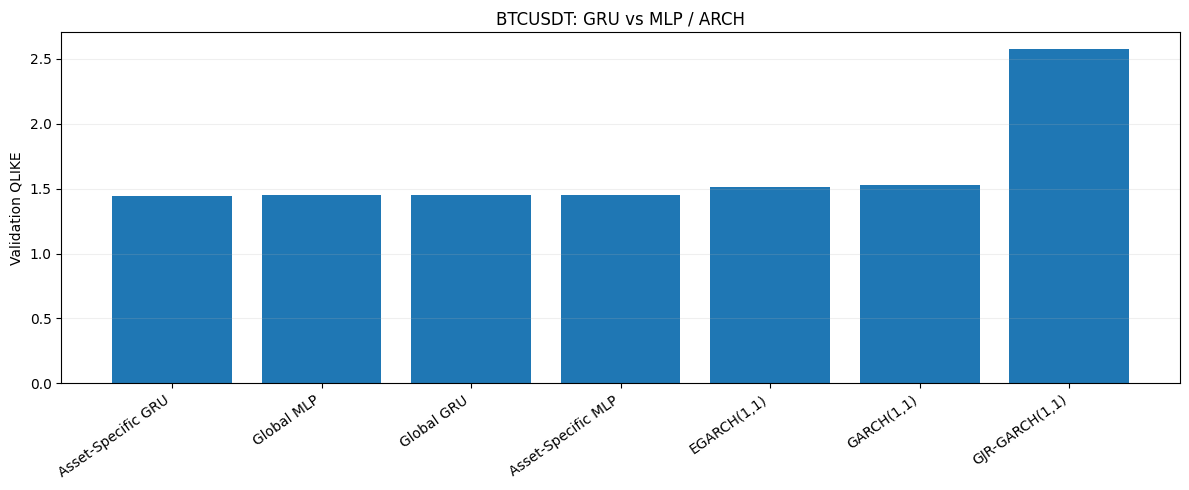

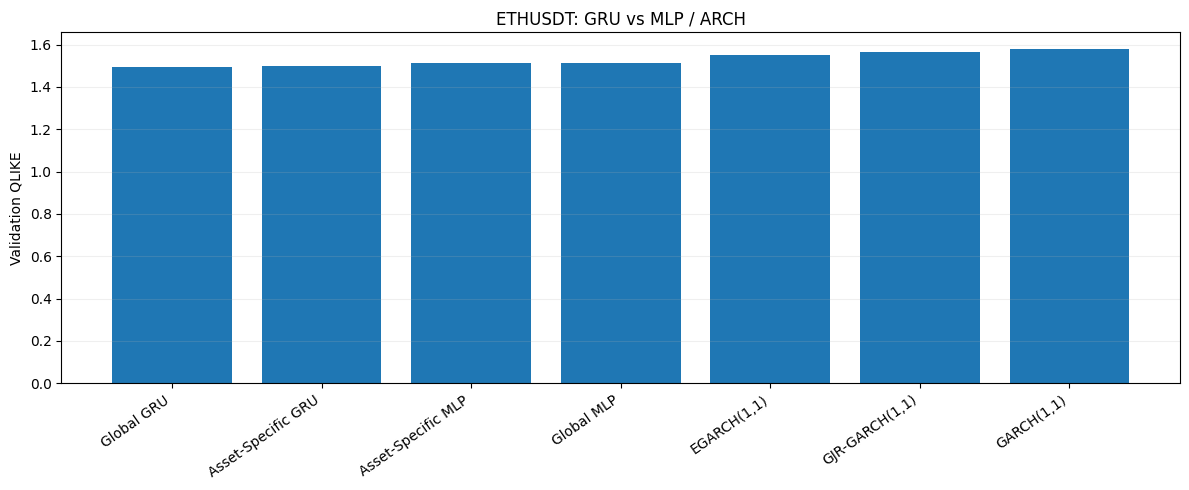

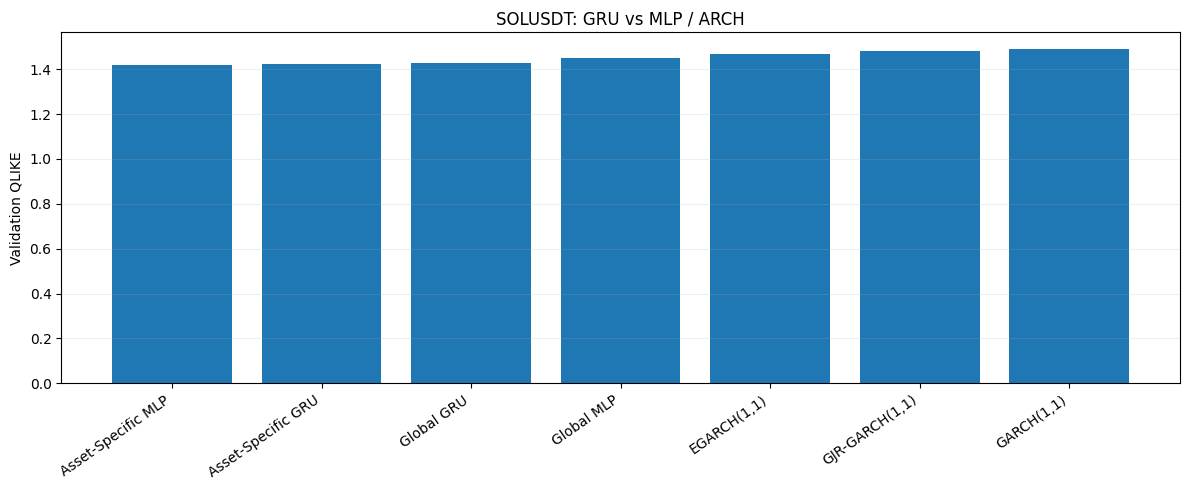

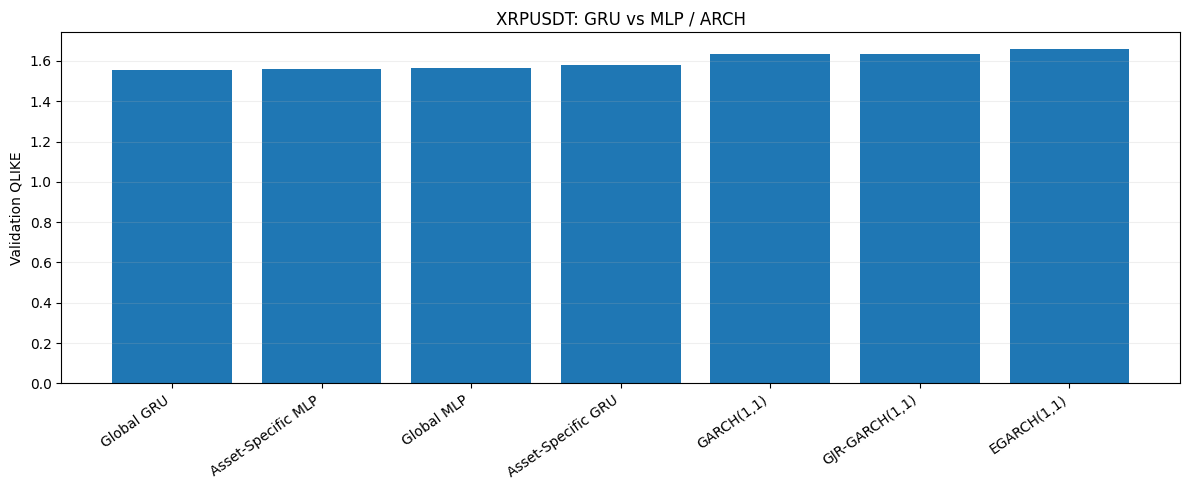

In [26]:
for symbol in SYMBOLS:
    x=fair_comparison_df.loc[fair_comparison_df["symbol"].eq(symbol)].sort_values("qlike")
    plt.figure(figsize=(12,5))
    plt.bar(x["model"],x["qlike"])
    plt.ylabel("Validation QLIKE")
    plt.title(f"{symbol}: GRU vs MLP / ARCH")
    plt.xticks(rotation=35,ha="right")
    plt.grid(axis="y",alpha=0.2)
    plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_gru_mlp_arch_qlike.png",dpi=200,bbox_inches="tight")
    plt.show()

# Part G — Dynamic volatility plots

## 27. Rolling historical-volatility proxy and plots

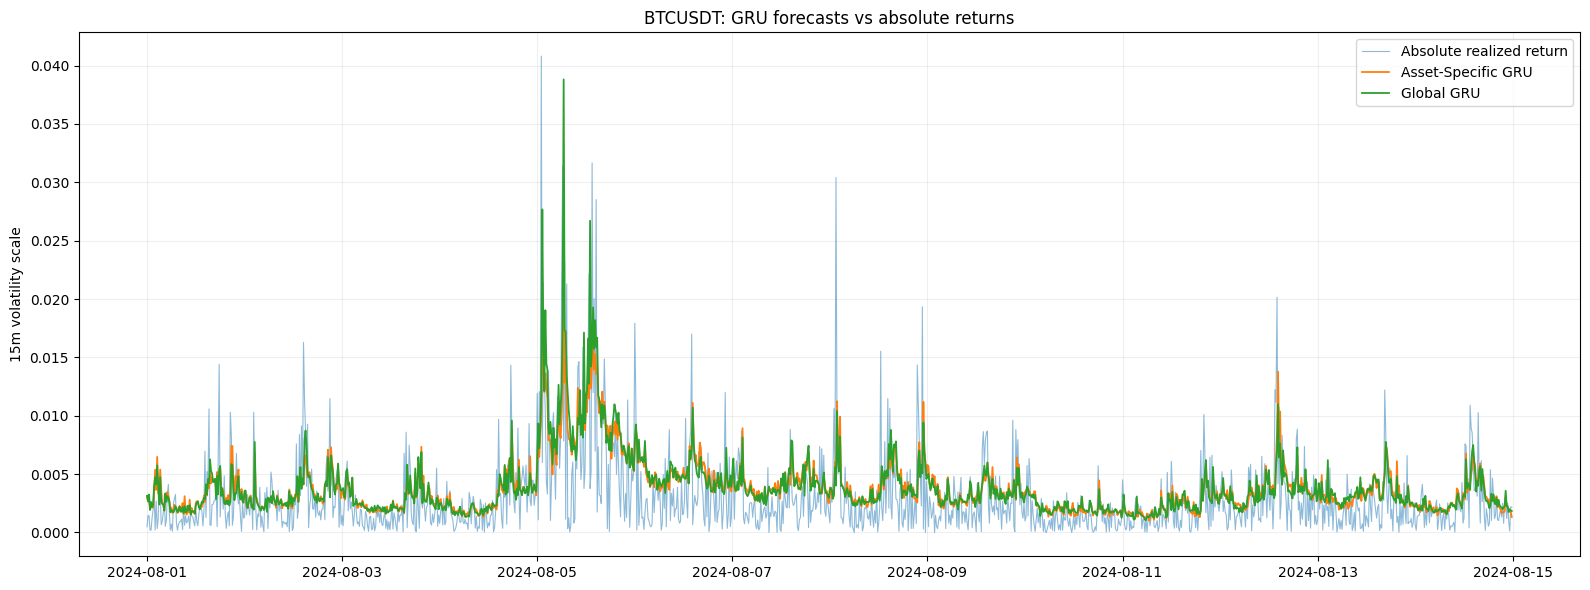

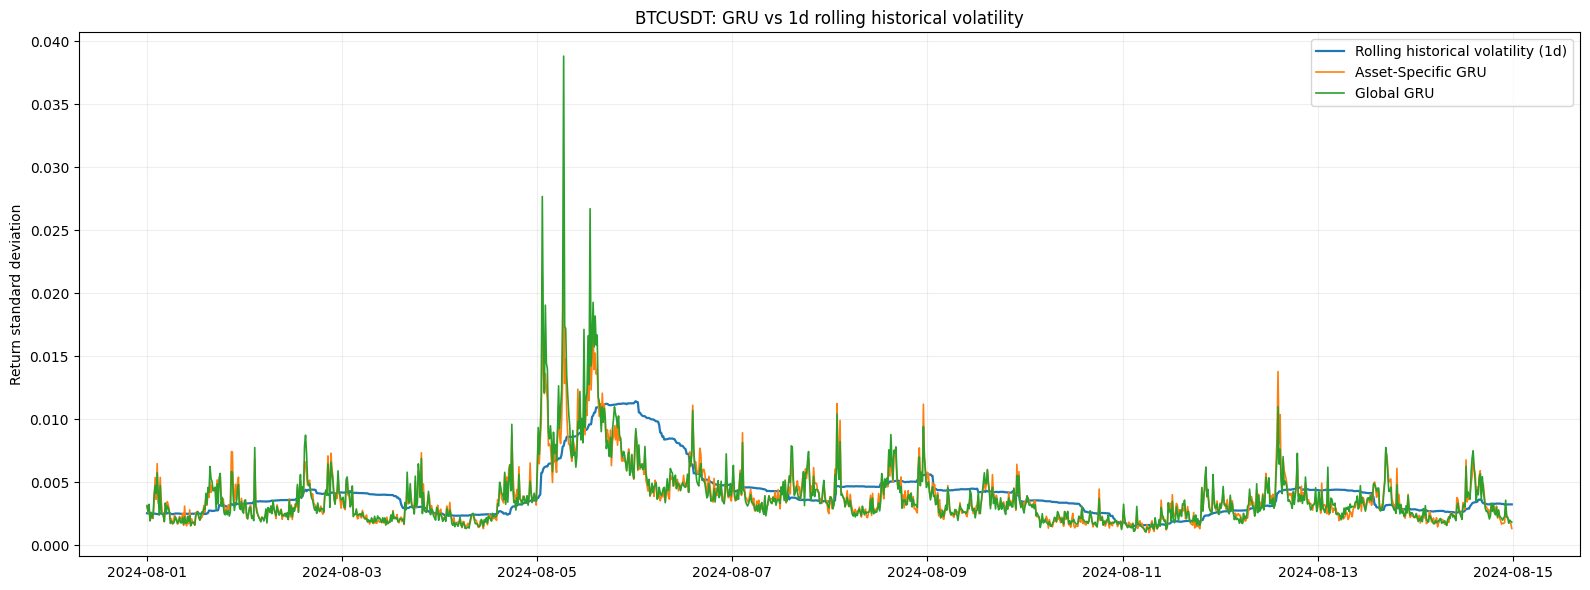

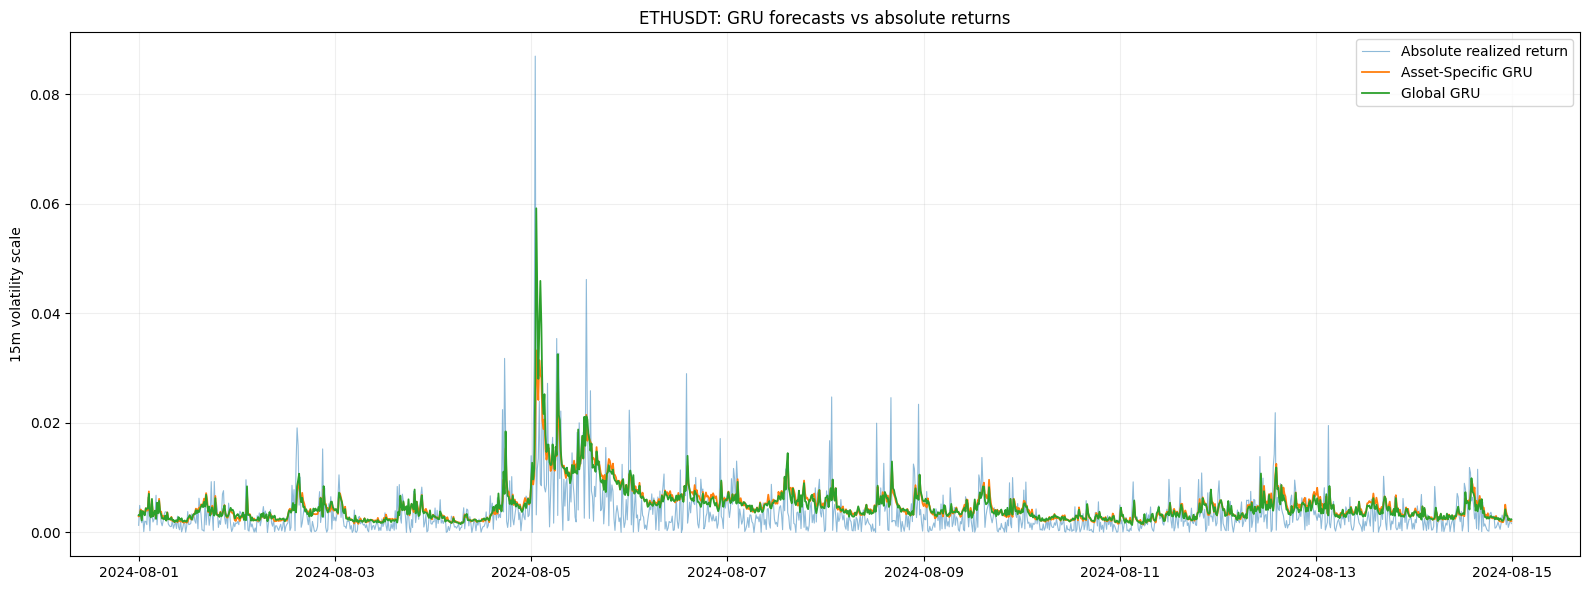

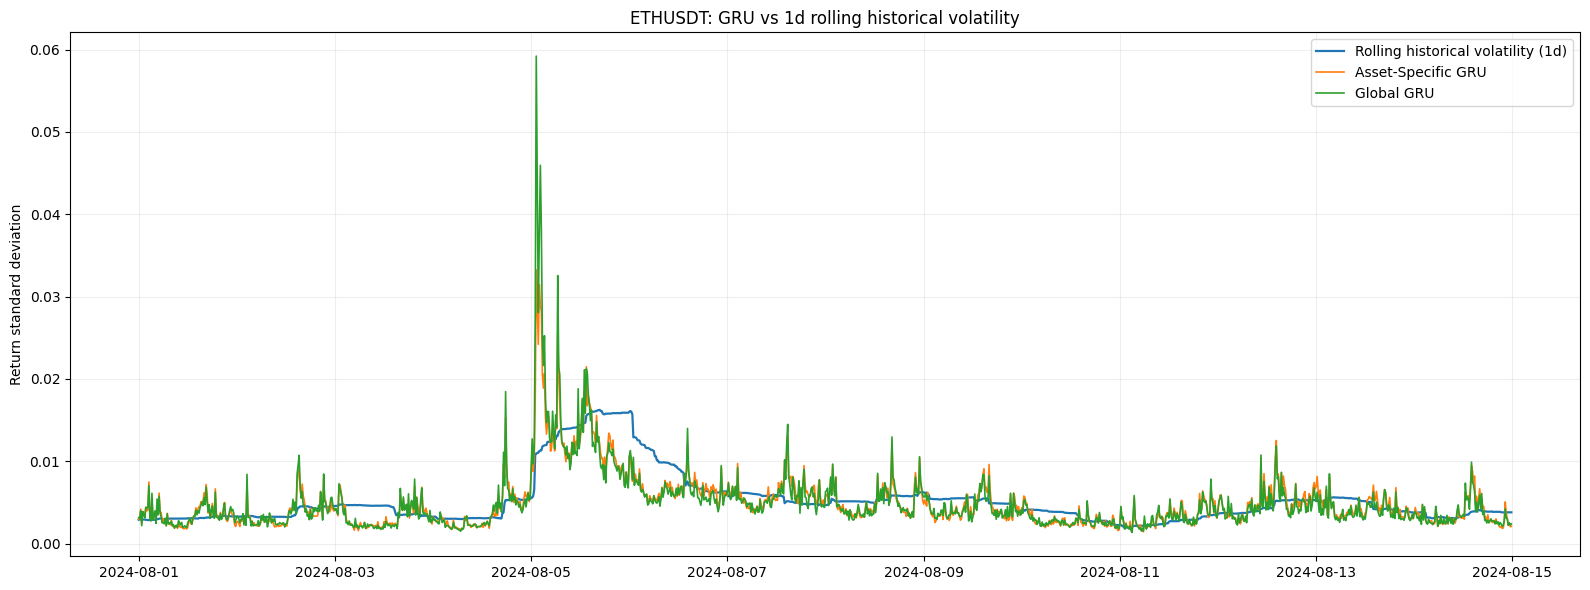

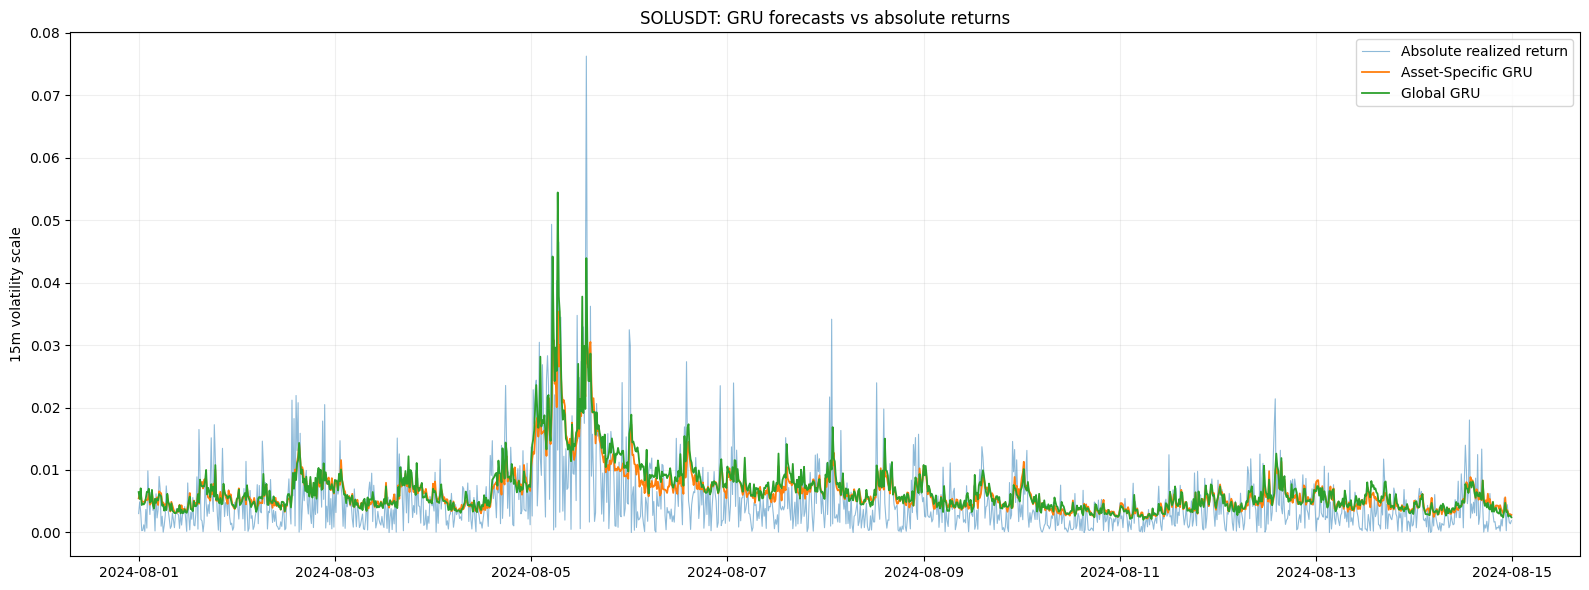

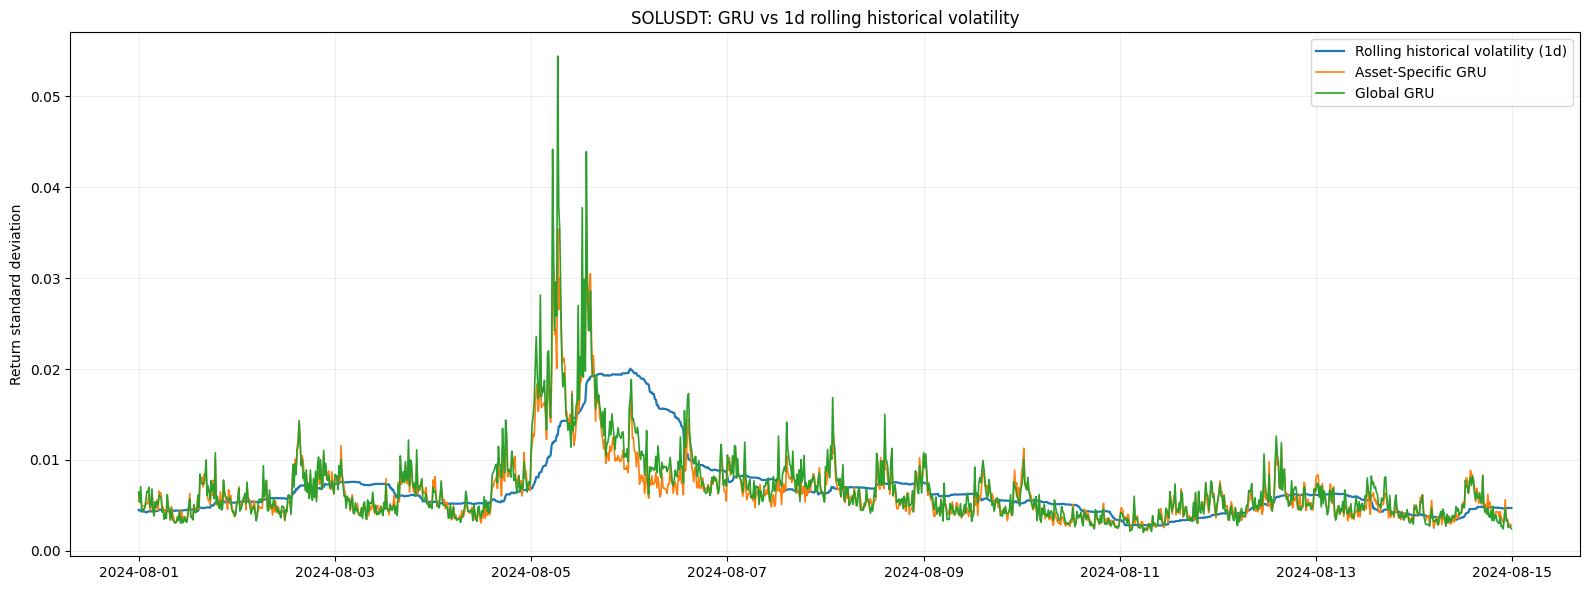

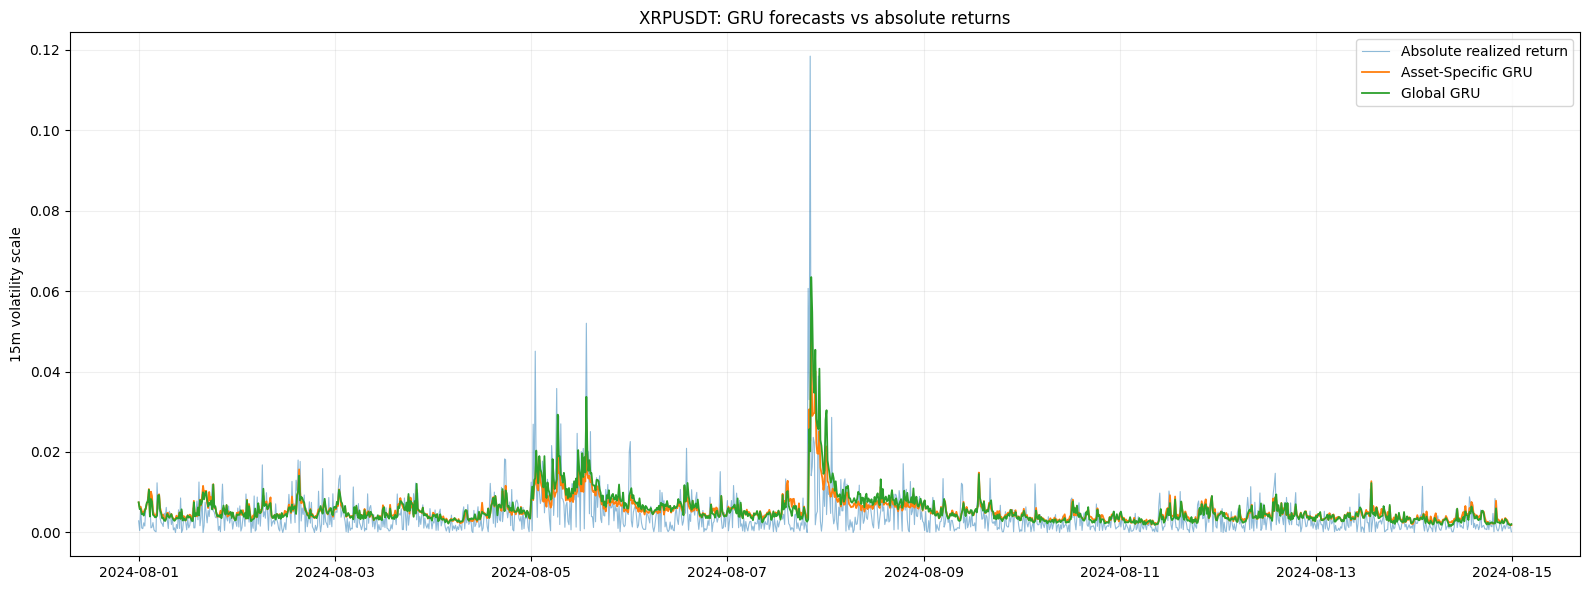

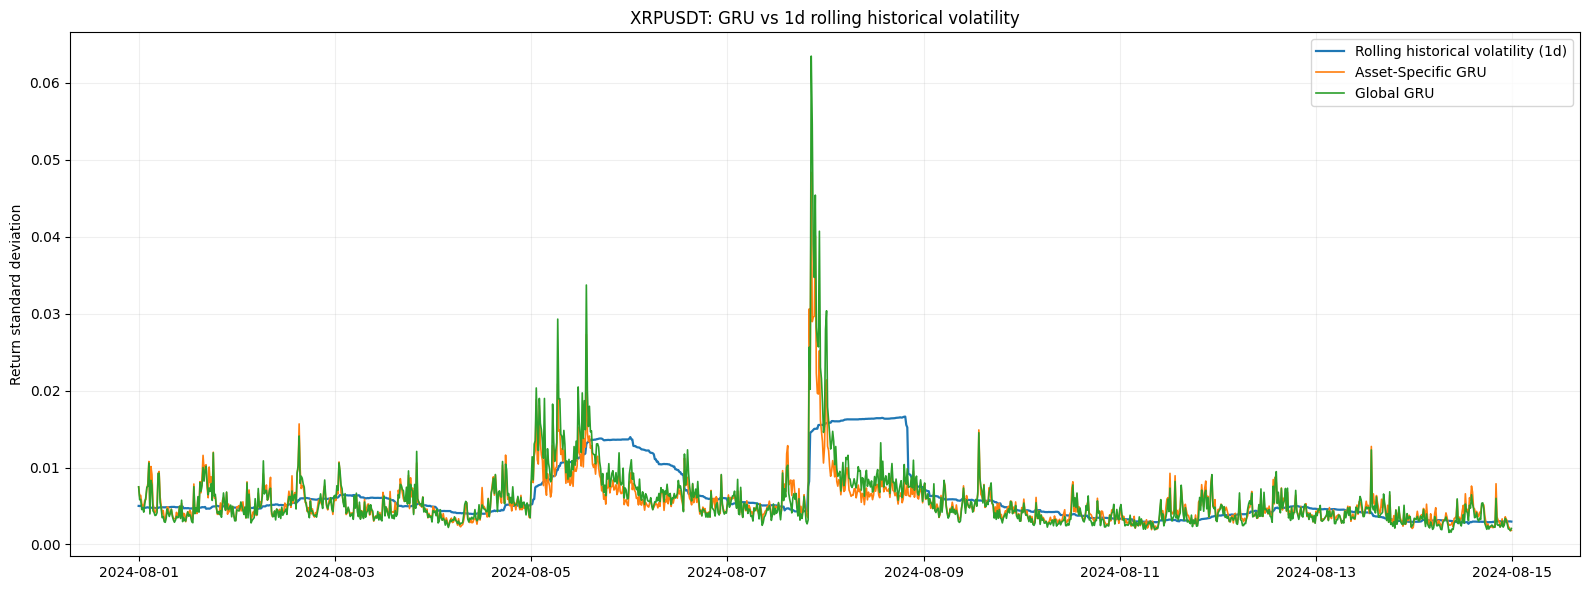

In [27]:
def strict_rolling_std(values,times,bars,ddof=1):
    std=values.rolling(bars,min_periods=bars).std(ddof=ddof)
    count=values.rolling(bars,min_periods=bars).count()
    start=times.shift(bars-1)
    exact=(times-start).eq((bars-1)*INTERVAL_DELTA)
    return std.where(count.eq(bars)&exact)

ROLLING_VOLATILITY_BARS=duration_to_bars_or_none(ROLLING_VOLATILITY_WINDOW)
if ROLLING_VOLATILITY_BARS is None or ROLLING_VOLATILITY_BARS<2:
    raise ValueError("Invalid rolling-volatility window.")

parts=[]
for symbol in SYMBOLS:
    x=features_df.loc[features_df["symbol"].eq(symbol)].sort_values("open_time").copy()
    x["absolute_return"]=x["return"].abs()
    x["rolling_historical_volatility"]=strict_rolling_std(
        x["return"],x["open_time"],ROLLING_VOLATILITY_BARS,1
    )
    parts.append(
        x[["symbol","open_time","absolute_return","rolling_historical_volatility"]]
        .rename(columns={"open_time":"target_open_time"})
    )
proxy_df=pd.concat(parts,ignore_index=True)

plot_df=(
    proxy_df
    .merge(
        asset_gru_predictions_df[["symbol","target_open_time","predicted_variance"]]
        .rename(columns={"predicted_variance":"asset_gru_variance"}),
        on=["symbol","target_open_time"],how="inner",validate="one_to_one"
    )
    .merge(
        global_gru_predictions_df[["symbol","target_open_time","predicted_variance"]]
        .rename(columns={"predicted_variance":"global_gru_variance"}),
        on=["symbol","target_open_time"],how="inner",validate="one_to_one"
    )
)

plot_df["asset_gru_volatility"]=np.sqrt(plot_df["asset_gru_variance"])
plot_df["global_gru_volatility"]=np.sqrt(plot_df["global_gru_variance"])

plot_start=VALIDATION_START if PLOT_START is None else pd.Timestamp(PLOT_START)
if plot_start.tzinfo is None:
    plot_start=plot_start.tz_localize("UTC")
else:
    plot_start=plot_start.tz_convert("UTC")
plot_end=plot_start+pd.Timedelta(PLOT_WINDOW_DURATION)

for symbol in SYMBOLS:
    x=plot_df.loc[
        plot_df["symbol"].eq(symbol)
        & plot_df["target_open_time"].ge(plot_start)
        & plot_df["target_open_time"].lt(plot_end)
    ].sort_values("target_open_time")

    plt.figure(figsize=(16,6))
    plt.plot(x["target_open_time"],x["absolute_return"],label="Absolute realized return",linewidth=0.8,alpha=0.5)
    plt.plot(x["target_open_time"],x["asset_gru_volatility"],label="Asset-Specific GRU",linewidth=1.3)
    plt.plot(x["target_open_time"],x["global_gru_volatility"],label="Global GRU",linewidth=1.3)
    plt.title(f"{symbol}: GRU forecasts vs absolute returns")
    plt.ylabel(f"{KLINE_INTERVAL} volatility scale")
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_gru_vs_absolute_return.png",dpi=200,bbox_inches="tight")
    plt.show()

    y=x.loc[x["rolling_historical_volatility"].notna()]
    plt.figure(figsize=(16,6))
    plt.plot(y["target_open_time"],y["rolling_historical_volatility"],label=f"Rolling historical volatility ({ROLLING_VOLATILITY_WINDOW})",linewidth=1.6)
    plt.plot(y["target_open_time"],y["asset_gru_volatility"],label="Asset-Specific GRU",linewidth=1.2)
    plt.plot(y["target_open_time"],y["global_gru_volatility"],label="Global GRU",linewidth=1.2)
    plt.title(f"{symbol}: GRU vs {ROLLING_VOLATILITY_WINDOW} rolling historical volatility")
    plt.ylabel("Return standard deviation")
    plt.legend(); plt.grid(alpha=0.2); plt.tight_layout()
    plt.savefig(RESULTS_ROOT/f"{symbol}_gru_vs_rolling_{duration_tag(ROLLING_VOLATILITY_WINDOW)}.png",dpi=200,bbox_inches="tight")
    plt.show()

# Part H — Save outputs and final QC

## 28. Save outputs

In [28]:
paths={
    "lookback_metrics":INNER_RESULTS_ROOT/"gru_lookback_inner_metrics.csv",
    "lookback_summary":INNER_RESULTS_ROOT/"gru_lookback_summary.csv",
    "lookback_histories":INNER_RESULTS_ROOT/"gru_lookback_histories.csv",
    "lr_metrics":INNER_RESULTS_ROOT/"gru_lr_inner_metrics.csv",
    "lr_summary":INNER_RESULTS_ROOT/"gru_lr_summary.csv",
    "global_inner_history":INNER_RESULTS_ROOT/"global_gru_inner_history.csv",
    "asset_metrics":RESULTS_ROOT/"asset_specific_gru_validation_metrics.csv",
    "asset_predictions":RESULTS_ROOT/"asset_specific_gru_validation_predictions.parquet",
    "asset_training":RESULTS_ROOT/"asset_specific_gru_training_summary.csv",
    "global_metrics":RESULTS_ROOT/"global_gru_validation_metrics.csv",
    "global_predictions":RESULTS_ROOT/"global_gru_validation_predictions.parquet",
    "comparison":RESULTS_ROOT/"gru_mlp_arch_validation_comparison.csv",
    "coverage":RESULTS_ROOT/"fair_validation_date_coverage.csv",
    "plot_data":RESULTS_ROOT/f"gru_volatility_plot_data_{duration_tag(ROLLING_VOLATILITY_WINDOW)}.parquet",
    "config":RESULTS_ROOT/"final_gru_configuration.json",
}

lookback_metrics_df.to_csv(paths["lookback_metrics"],index=False)
lookback_summary_df.to_csv(paths["lookback_summary"],index=False)
lookback_histories_df.to_csv(paths["lookback_histories"],index=False)
lr_metrics_df.to_csv(paths["lr_metrics"],index=False)
lr_summary_df.to_csv(paths["lr_summary"],index=False)
global_inner_history_df.to_csv(paths["global_inner_history"],index=False)
asset_gru_metrics_df.to_csv(paths["asset_metrics"],index=False)
asset_gru_predictions_df.to_parquet(paths["asset_predictions"],index=False)
asset_gru_training_df.to_csv(paths["asset_training"],index=False)
global_gru_metrics_df.to_csv(paths["global_metrics"],index=False)
global_gru_predictions_df.to_parquet(paths["global_predictions"],index=False)
fair_comparison_df.to_csv(paths["comparison"],index=False)
comparison_dates_df.to_csv(paths["coverage"],index=False)
plot_df.to_parquet(paths["plot_data"],index=False)

config={
    "created_at_utc":datetime.now(timezone.utc).isoformat(),
    "model_family":"Final Enhanced GRU",
    "kline_interval":KLINE_INTERVAL,
    "interval_minutes":INTERVAL_MINUTES,
    "forecast_horizon":"one_candle_ahead",
    "target":"next_candle_squared_log_return",
    "training_target":"deseasonalized_next_candle_variance",
    "loss":"gaussian_variance_quasi_likelihood_qlike_aligned",
    "official_validation_used_for_selection":False,
    "inner_tuning_start":INNER_TUNE_START.isoformat(),
    "available_sequence_lookbacks":AVAILABLE_SEQUENCE_LOOKBACKS,
    "selected_sequence_duration":SELECTED_GRU_DURATION,
    "selected_sequence_bars":SELECTED_GRU_BARS,
    "selected_learning_rate":SELECTED_GRU_LR,
    "selected_epoch_by_asset":SELECTED_EPOCH_BY_ASSET,
    "global_selected_epochs":GLOBAL_FINAL_EPOCHS,
    "state_features":STATE_FEATURE_COLUMNS,
    "sequence_features":SEQUENCE_FEATURE_COLUMNS,
    "gru_units":GRU_UNITS,
    "temporal_attention":True,
    "global_asset_balanced_weights":True,
    "rolling_volatility_window":ROLLING_VOLATILITY_WINDOW,
    "test_evaluated":False,
}
paths["config"].write_text(json.dumps(config,indent=2))

print("Saved GRU outputs.")

Saved GRU outputs.


## 29. Final QC

In [29]:
for pred_df in [asset_gru_predictions_df,global_gru_predictions_df]:
    pred_df["target_open_time"]=pd.to_datetime(pred_df["target_open_time"],utc=True)
    assert pred_df["target_open_time"].ge(VALIDATION_START).all()
    assert pred_df["target_open_time"].lt(TEST_START).all()
    assert np.isfinite(pred_df["predicted_variance"].to_numpy(float)).all()
    assert pred_df["predicted_variance"].gt(0).all()

assert asset_gru_metrics_df["symbol"].nunique()==len(SYMBOLS)
assert global_gru_metrics_df["symbol"].nunique()==len(SYMBOLS)

assert SELECTED_GRU_DURATION in AVAILABLE_SEQUENCE_LOOKBACKS
assert SELECTED_GRU_BARS==AVAILABLE_SEQUENCE_LOOKBACKS[SELECTED_GRU_DURATION]
assert any(np.isclose(SELECTED_GRU_LR,x) for x in LEARNING_RATE_CANDIDATES)

for symbol in SYMBOLS:
    current=fair_comparison_df.loc[fair_comparison_df["symbol"].eq(symbol)]
    expected={
        "Asset-Specific GRU","Global GRU",
        "Asset-Specific MLP","Global MLP",
        "GARCH(1,1)","GJR-GARCH(1,1)","EGARCH(1,1)"
    }
    assert set(current["model"])==expected
    assert (MODEL_ROOT/symbol/"final_asset_specific_gru.keras").exists()
    assert (ARTIFACT_ROOT/symbol/"gru_scalers.joblib").exists()

assert GLOBAL_MODEL_PATH.exists()
assert GLOBAL_SCALERS_PATH.exists()

print("ALL FINAL INTRADAY GRU QC CHECKS PASSED.")
print("Selected GRU lookback:",SELECTED_GRU_DURATION,"=",SELECTED_GRU_BARS,"bars")
print("Selected LR:",SELECTED_GRU_LR)
print("Global epochs:",GLOBAL_FINAL_EPOCHS)
print("\nTest remains untouched.")
display(fair_comparison_df)
# Additional prediction / metric integrity QC.
for _pred_df in [asset_gru_predictions_df, global_gru_predictions_df]:
    assert not _pred_df.duplicated(["symbol", "target_open_time"]).any()
    assert _pred_df["actual_variance"].ge(0).all()
    assert np.isfinite(_pred_df["actual_variance"].to_numpy(float)).all()

for _metric_df in [asset_gru_metrics_df, global_gru_metrics_df]:
    assert np.isfinite(_metric_df[["mae", "rmse", "qlike"]].to_numpy(float)).all()
    assert _metric_df["qlike"].ge(-1e-12).all()

print("Additional prediction/metric QC passed.")


ALL FINAL INTRADAY GRU QC CHECKS PASSED.
Selected GRU lookback: 4h = 16 bars
Selected LR: 0.0003
Global epochs: 8

Test remains untouched.


,symbol,model,model_family,observations,mae,rmse,qlike,qlike_rank
0,BTCUSDT,Asset-Specific GRU,Deep Learning,35040,0.000008,0.000030,1.446041,1
1,BTCUSDT,Global MLP,Deep Learning,35040,0.000008,0.000031,1.449854,2
2,BTCUSDT,Global GRU,Deep Learning,35040,0.000008,0.000031,1.450973,3
3,BTCUSDT,Asset-Specific MLP,Deep Learning,35040,0.000007,0.000030,1.451999,4
4,BTCUSDT,"EGARCH(1,1)",ARCH,35040,0.000008,0.000030,1.515321,5
5,BTCUSDT,"GARCH(1,1)",ARCH,35040,0.000008,0.000030,1.526979,6
6,BTCUSDT,"GJR-GARCH(1,1)",ARCH,35040,0.000028,0.000039,2.575465,7
7,ETHUSDT,Global GRU,Deep Learning,35040,0.000018,0.000103,1.495209,1
8,ETHUSDT,Asset-Specific GRU,Deep Learning,35040,0.000017,0.000096,1.498512,2
9,ETHUSDT,Asset-Specific MLP,Deep Learning,35040,0.000017,0.000094,1.511114,3


Additional prediction/metric QC passed.


# Research rationale

The final GRU is intentionally more structured than a generic raw-sequence recurrent network.

Recent volatility-forecasting work supports several design choices used here:

- explicit intraday periodicity handling is important in high-frequency volatility models;
- heterogeneous / multi-scale volatility state is difficult to ignore because realized volatility exhibits strong persistence and long memory;
- recent work on memory-augmented GRUs specifically targets the short-memory limitation of standard GRUs for multivariate realized-volatility forecasting;
- HAR-GRU hybrid work supports combining explicit volatility-state variables with nonlinear recurrent dynamics;
- high-frequency recurrent models benefit from richer OHLC / activity information rather than price history alone;
- the loss is aligned to QLIKE so optimization matches the primary volatility-forecast evaluation criterion.

The notebook remains a standalone GRU comparison: it does not use a GARCH forecast as an input.

Test is sealed until GRU, LSTM and the final comparison design are frozen.